# Librerías

In [3]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import welch, butter, filtfilt
from scipy.integrate import trapezoid
import seaborn as sns
import pandas as pd
import ast
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Carga de Datos

Carga -- Resamplear a 100 Hz -- Guardar en dict. individual -- Verificar -- Unir todo a un dict. total -- Cargarlo a un archivo HDF5 para no sobrecargar la RAM

**Estandarización:** El objetivo de esta fase es que todas las bases de datos crudas terminen en el mismo formato.

## PTB-XL

In [4]:
import os
import ast
import pandas as pd
from pathlib import Path
import wfdb  # Librería para leer archivos .dat y .hea de PhysioNet
import h5py  # Para guardar en disco

# 1. Tu código original de carga
PATH_DATA = Path('../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3') 

if not PATH_DATA.exists():
    print(f"Error: No se encontró la carpeta de datos en {PATH_DATA.resolve()}")
else:
    df_meta = pd.read_csv(os.path.join(PATH_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
    df_meta['scp_codes'] = df_meta['scp_codes'].apply(lambda x: ast.literal_eval(x))
    print("¡Dataset de metadatos cargado exitosamente!")

# 2. Lógica para procesar las señales de 100 Hz y guardarlas
print("Iniciando extracción y guardado de señales a 100 Hz...")

# Creamos nuestro contenedor HDF5 final
with h5py.File('ptbxl_procesado_100hz.h5', 'w') as hf:
    
    # Iteramos sobre cada fila del DataFrame usando el ecg_id
    for ecg_id, fila in df_meta.iterrows():
        
        # 'filename_lr' tiene rutas como "records100/00000/00001_lr"
        ruta_relativa_100hz = fila['filename_lr'] 
        ruta_completa = os.path.join(PATH_DATA, ruta_relativa_100hz)
        
        try:
            # wfdb.rdrecord lee automáticamente los archivos .dat y .hea
            registro = wfdb.rdrecord(ruta_completa)
            
            # Extraemos la matriz de la señal (numpy array)
            # Para PTB-XL, esto suele ser un array de forma (1000, 12) -> 10 seg * 100Hz, 12 derivaciones
            matriz_senal = registro.p_signal 
            
            # Guardamos la matriz en el HDF5 usando el ecg_id como llave
            hf.create_dataset(str(ecg_id), data=matriz_senal)
            
        except Exception as e:
            print(f"Error procesando el registro {ecg_id}: {e}")

print("¡Proceso completado! Todas las señales de 100 Hz están en el archivo HDF5.")

¡Dataset de metadatos cargado exitosamente!
Iniciando extracción y guardado de señales a 100 Hz...
¡Proceso completado! Todas las señales de 100 Hz están en el archivo HDF5.


¡Archivo cargado! Contiene 21799 registros en total.
Forma de la señal extraída: (1000, 12)


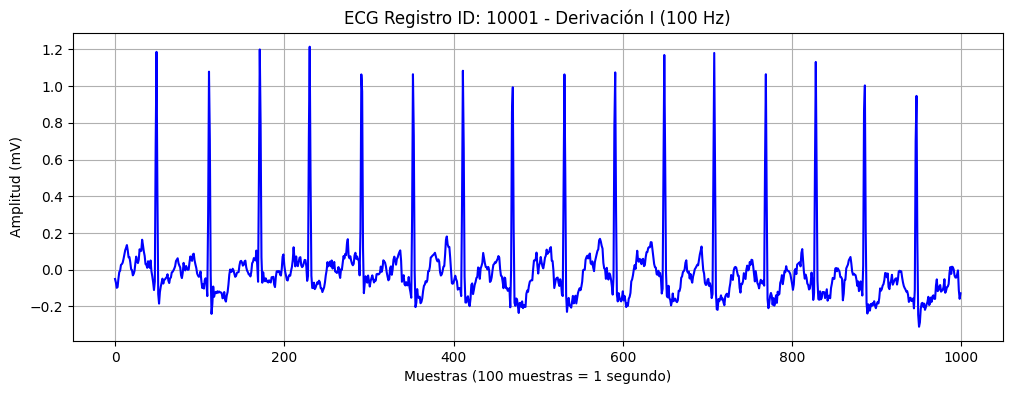

In [5]:
import h5py
import matplotlib.pyplot as plt

# 1. Abrimos el archivo en modo lectura ('r')
with h5py.File('ptbxl_procesado_100hz.h5', 'r') as hf:
    
    # Obtenemos una lista de todos los IDs guardados
    todos_los_ids = list(hf.keys())
    print(f"¡Archivo cargado! Contiene {len(todos_los_ids)} registros en total.")
    
    # Seleccionamos el primer registro de la lista
    primer_id = todos_los_ids[5]  # Cambia el índice según el registro que quieras visualizar
    
    # Extraemos la matriz de la señal a la memoria RAM
    matriz_senal = hf[primer_id][:]

# 2. Imprimimos la forma de la matriz (debería ser 1000 muestras x 12 derivaciones)
print(f"Forma de la señal extraída: {matriz_senal.shape}")

# 3. Graficamos la primera derivación (columna 0)
plt.figure(figsize=(12, 4))
plt.plot(matriz_senal[:, 0], color='blue') 
plt.title(f"ECG Registro ID: {primer_id} - Derivación I (100 Hz)")
plt.xlabel("Muestras (100 muestras = 1 segundo)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

In [6]:
import pandas as pd
import ast
import os

# Ruta al archivo original de PTB-XL
ruta_ptbxl_csv = '../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/ptbxl_database.csv'

if os.path.exists(ruta_ptbxl_csv):
    print("Cargando base de datos PTB-XL...")
    df_ptbxl_original = pd.read_csv(ruta_ptbxl_csv, index_col='ecg_id')
    
    # Función para buscar una clase específica en el diccionario de diagnósticos
    def extraer_clase(scp_string, clase_buscada):
        try:
            diccionario_dx = ast.literal_eval(scp_string)
            if clase_buscada in diccionario_dx.keys():
                return 1
            return 0
        except:
            return 0

    print("Extrayendo clases específicas del pipeline...")
    clases_pipeline = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB']
    
    # Creamos una columna por cada clase que mencionaste
    for clase in clases_pipeline:
        df_ptbxl_original[clase] = df_ptbxl_original['scp_codes'].apply(lambda x: extraer_clase(x, clase))
    
    # Armamos la tabla final estandarizada con todas las columnas nuevas
    columnas_finales = ['ecg_id'] + clases_pipeline
    df_ptbxl_limpio = df_ptbxl_original.reset_index()[columnas_finales]
    
    # Renombramos para estandarizar
    df_ptbxl_limpio.rename(columns={'ecg_id': 'id_registro'}, inplace=True)
    df_ptbxl_limpio['id_registro'] = df_ptbxl_limpio['id_registro'].astype(str)
    
    ruta_ptbxl_out = '../data/processed/ptbxl_etiquetas.csv'
    df_ptbxl_limpio.to_csv(ruta_ptbxl_out, index=False)
    
    print("\n" + "="*40)
    print("--- RESUMEN DE DIAGNÓSTICOS DETALLADOS EN PTB-XL ---")
    print("="*40)
    print(f"Total de registros guardados: {len(df_ptbxl_limpio)}")
    for clase in clases_pipeline:
        print(f"Pacientes con {clase}: {df_ptbxl_limpio[clase].sum()}")
    print("="*40)
    print(f"Archivo guardado en: {ruta_ptbxl_out}")

else:
    print(f"Error: No se encontró el archivo csv en la ruta: {ruta_ptbxl_csv}")

Cargando base de datos PTB-XL...
Extrayendo clases específicas del pipeline...

--- RESUMEN DE DIAGNÓSTICOS DETALLADOS EN PTB-XL ---
Total de registros guardados: 21799
Pacientes con NORM: 9514
Pacientes con IRBBB: 1118
Pacientes con CRBBB: 541
Pacientes con CLBBB: 536
Pacientes con ILBBB: 77
Archivo guardado en: ../data/processed/ptbxl_etiquetas.csv


## CPSC 2018

In [9]:
import os
from pathlib import Path
import wfdb
import h5py
import numpy as np
from scipy.signal import resample
from tqdm import tqdm

# 1. Definimos la ruta a la carpeta Training_WFDB
PATH_CPSC = Path('../data/raw/Training_WFDB')

if not PATH_CPSC.exists():
    print(f"Error: No se encontró la carpeta en {PATH_CPSC.resolve()}")
else:
    # wfdb usa dos archivos por registro (.hea y .mat/.dat). 
    # Buscamos todos los .hea y nos quedamos con el nombre sin la extensión.
    archivos_hea = list(PATH_CPSC.glob('*.hea'))
    nombres_registros = [str(archivo.with_suffix('')) for archivo in archivos_hea]
    
    print(f"¡Carpeta encontrada! Se detectaron {len(nombres_registros)} registros para procesar.")
    
    # Frecuencia objetivo para unificar
    fs_objetivo = 100
    
    # 2. Creamos el contenedor HDF5 para esta base de datos
    with h5py.File('cpsc2018_procesado_100hz.h5', 'w') as hf:
        
        # 3. Iteramos con barra de progreso
        for ruta_registro in tqdm(nombres_registros, desc="Resampleando CPSC 2018"):
            
            # Extraemos solo el ID del archivo (ej: 'A0001')
            id_registro = os.path.basename(ruta_registro)
            
            try:
                # Leemos el registro original
                registro = wfdb.rdrecord(ruta_registro)
                senal_original = registro.p_signal
                fs_original = registro.fs
                
                # Verificamos que haya datos
                if senal_original is None:
                    continue
                
                # 4. Resampleo (si la frecuencia original es distinta a la objetivo)
                if fs_original != fs_objetivo:
                    # Calculamos el nuevo número de muestras
                    # axis=0 asegura que resamplea a lo largo del tiempo, no de las 12 derivaciones
                    muestras_nuevas = int(senal_original.shape[0] * (fs_objetivo / fs_original))
                    senal_procesada = resample(senal_original, muestras_nuevas, axis=0)
                else:
                    # Si por algún motivo ya está a 100Hz, la dejamos igual
                    senal_procesada = senal_original
                    
                # 5. Guardamos en el HDF5
                hf.create_dataset(id_registro, data=senal_procesada)
                
            except Exception as e:
                print(f"\nError procesando el registro {id_registro}: {e}")

    print("\n¡Proceso de CPSC 2018 completado! Señales resampleadas y guardadas a 100 Hz.")

¡Carpeta encontrada! Se detectaron 6877 registros para procesar.


Resampleando CPSC 2018: 100%|██████████| 6877/6877 [03:31<00:00, 32.53it/s]


¡Proceso de CPSC 2018 completado! Señales resampleadas y guardadas a 100 Hz.


¡Archivo cargado! Contiene 6877 registros en total.
Forma de la señal extraída: (1400, 12)


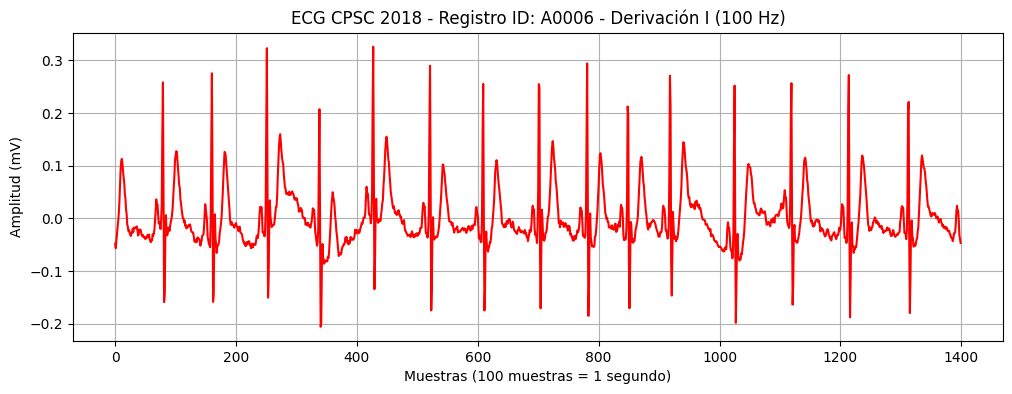

In [10]:
import h5py
import matplotlib.pyplot as plt

# 1. Abrimos el archivo contenedor de CPSC 2018
with h5py.File('cpsc2018_procesado_100hz.h5', 'r') as hf:
    
    # Obtenemos todos los IDs (En CPSC suelen llamarse 'A0001', 'A0002', etc.)
    todos_los_ids_cpsc = list(hf.keys())
    print(f"¡Archivo cargado! Contiene {len(todos_los_ids_cpsc)} registros en total.")
    
    # Seleccionamos el primer registro
    primer_id_cpsc = todos_los_ids_cpsc[5]  # Cambia el índice según el registro que quieras visualizar
    
    # Extraemos la señal a la memoria
    matriz_senal_cpsc = hf[primer_id_cpsc][:]

# 2. Imprimimos la forma de la matriz
print(f"Forma de la señal extraída: {matriz_senal_cpsc.shape}")

# 3. Graficamos la primera derivación (columna 0)
plt.figure(figsize=(12, 4))
plt.plot(matriz_senal_cpsc[:, 0], color='red') # Usamos rojo para distinguirlo de PTB-XL
plt.title(f"ECG CPSC 2018 - Registro ID: {primer_id_cpsc} - Derivación I (100 Hz)")
plt.xlabel("Muestras (100 muestras = 1 segundo)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

A diferencia de PTB-XL estos registros son de duración variable por eso podemos ver 1400 o 1500 muestras. Esto debe ser considerado a la hora de diseñar la arquitectura de la red neuronal.

Esta base de datos identifica LBBB (Bloqueo Izquierdo) y RBBB (Bloqueo Derecho)

In [11]:
import os
from pathlib import Path
import wfdb
from collections import Counter
from tqdm import tqdm

# Apuntamos a la carpeta de CPSC 2018
PATH_CPSC = Path('../data/raw/Training_WFDB')

if PATH_CPSC.exists():
    archivos_hea = list(PATH_CPSC.glob('*.hea'))
    rutas_registros = [str(a.with_suffix('')) for a in archivos_hea]
    
    todos_los_dx = []
    
    for ruta in tqdm(rutas_registros, desc="Explorando diagnósticos ocultos"):
        try:
            header = wfdb.rdheader(ruta)
            
            for comentario in header.comments:
                if comentario.startswith('Dx:'):
                    # Extraemos todo lo que haya después de 'Dx:'
                    codigos_crudos = comentario.replace('Dx:', '').strip().split(',')
                    # Limpiamos espacios en blanco de cada código
                    codigos_limpios = [c.strip() for c in codigos_crudos]
                    # Los agregamos a nuestra lista maestra
                    todos_los_dx.extend(codigos_limpios)
                    
        except Exception as e:
            pass

    # Contamos las frecuencias de cada código encontrado
    conteo_dx = Counter(todos_los_dx)
    
    print("\n" + "="*60)
    print("--- TODOS LOS CÓDIGOS ENCONTRADOS EN CPSC 2018 ---")
    print("="*60)
    
    # Imprimimos del más común al menos común
    for codigo, cantidad in conteo_dx.most_common():
        print(f"Código exacto: '{codigo}' -> Presente en {cantidad} pacientes")

else:
    print("Error: No se encontró la carpeta Training_WFDB.")

Explorando diagnósticos ocultos: 100%|██████████| 6877/6877 [00:54<00:00, 126.08it/s]


--- TODOS LOS CÓDIGOS ENCONTRADOS EN CPSC 2018 ---
Código exacto: '59118001' -> Presente en 1857 pacientes
Código exacto: '164889003' -> Presente en 1221 pacientes
Código exacto: '426783006' -> Presente en 918 pacientes
Código exacto: '429622005' -> Presente en 869 pacientes
Código exacto: '270492004' -> Presente en 722 pacientes
Código exacto: '164884008' -> Presente en 700 pacientes
Código exacto: '284470004' -> Presente en 616 pacientes
Código exacto: '164909002' -> Presente en 236 pacientes
Código exacto: '164931005' -> Presente en 220 pacientes


In [12]:
import os
from pathlib import Path
import wfdb
import pandas as pd
from tqdm import tqdm

# Apuntamos a la carpeta de CPSC 2018
PATH_CPSC = Path('../data/raw/Training_WFDB')

# ¡CÓDIGOS EXACTOS REVELADOS POR NUESTRO SCRIPT!
SNOMED_LBBB = ['164909002'] 
SNOMED_RBBB = ['59118001'] # Código estricto para RBBB en CPSC 2018
SNOMED_NORM = ['426783006'] # Ritmo Sinusal Normal

if PATH_CPSC.exists():
    archivos_hea = list(PATH_CPSC.glob('*.hea'))
    rutas_registros = [str(a.with_suffix('')) for a in archivos_hea]
    
    resultados_cpsc = []
    
    for ruta in tqdm(rutas_registros, desc="Extrayendo etiquetas CPSC 2018"):
        id_registro = os.path.basename(ruta)
        
        try:
            header = wfdb.rdheader(ruta)
            comentarios = header.comments
            
            es_lbbb = 0
            es_rbbb = 0
            es_norm = 0
            
            for comentario in comentarios:
                if comentario.startswith('Dx:'):
                    codigos_dx = comentario.replace('Dx:', '').strip().split(',')
                    # Limpiamos los espacios igual que en nuestro script detective
                    codigos_limpios = [c.strip() for c in codigos_dx]
                    
                    if any(codigo in SNOMED_LBBB for codigo in codigos_limpios):
                        es_lbbb = 1
                    if any(codigo in SNOMED_RBBB for codigo in codigos_limpios):
                        es_rbbb = 1
                    if any(codigo in SNOMED_NORM for codigo in codigos_limpios):
                        es_norm = 1
            
            resultados_cpsc.append({
                'id_registro': id_registro,
                'LBBB': es_lbbb,
                'RBBB': es_rbbb,
                'NORM': es_norm
            })
            
        except Exception as e:
            pass

    df_cpsc = pd.DataFrame(resultados_cpsc)
    ruta_cpsc = '../data/processed/cpsc2018_etiquetas.csv'
    df_cpsc.to_csv(ruta_cpsc, index=False)
        
    print("\n" + "="*40)
    print("--- RESUMEN DEFINITIVO EN CPSC 2018 ---")
    print("="*40)
    print(f"Total de registros analizados: {len(df_cpsc)}")
    print(f"Pacientes con LBBB: {df_cpsc['LBBB'].sum()}")
    print(f"Pacientes con RBBB: {df_cpsc['RBBB'].sum()}")
    print(f"Pacientes con NORM: {df_cpsc['NORM'].sum()}")
    print(f"Archivo guardado en: {ruta_cpsc}")

else:
    print("Error: No se encontró la carpeta Training_WFDB.")

Extrayendo etiquetas CPSC 2018: 100%|██████████| 6877/6877 [00:53<00:00, 128.31it/s]



--- RESUMEN DEFINITIVO EN CPSC 2018 ---
Total de registros analizados: 6877
Pacientes con LBBB: 236
Pacientes con RBBB: 1857
Pacientes con NORM: 918
Archivo guardado en: ../data/processed/cpsc2018_etiquetas.csv


# Chapman-Shaoxing Database

In [15]:
import os
from pathlib import Path
import wfdb
import h5py
from scipy.signal import resample
from tqdm import tqdm

# Usamos el nombre exacto de la carpeta que me compartiste
NOMBRE_CARPETA = 'a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0'

# Asumiendo que tu Jupyter Notebook está en la carpeta 'notebooks'
PATH_CHAPMAN = Path(f'../data/raw/{NOMBRE_CARPETA}/WFDBRecords')

if PATH_CHAPMAN.exists():
    # Buscamos recursivamente todos los .hea (para que entre a las carpetas 01/010/, etc.)
    archivos_hea_chapman = list(PATH_CHAPMAN.rglob('*.hea'))
    nombres_registros_chapman = [str(archivo.with_suffix('')) for archivo in archivos_hea_chapman]
    
    print(f"¡Ruta exacta detectada en: {PATH_CHAPMAN.resolve()}!")
    print(f"Se detectaron {len(nombres_registros_chapman)} registros para procesar.")
    
    if len(nombres_registros_chapman) > 0:
        fs_objetivo = 100
        
        # Guardamos en la misma ubicación donde tienes tus otros .h5
        with h5py.File('chapman_shaoxing_procesado_100hz.h5', 'w') as hf:
            
            for ruta_registro in tqdm(nombres_registros_chapman, desc="Resampleando Chapman-Shaoxing"):
                
                id_registro = os.path.basename(ruta_registro)
                
                try:
                    registro = wfdb.rdrecord(ruta_registro)
                    senal_original = registro.p_signal
                    fs_original = registro.fs
                    
                    if senal_original is None:
                        continue
                    
                    if fs_original != fs_objetivo:
                        muestras_nuevas = int(senal_original.shape[0] * (fs_objetivo / fs_original))
                        senal_procesada = resample(senal_original, muestras_nuevas, axis=0)
                    else:
                        senal_procesada = senal_original
                        
                    hf.create_dataset(id_registro, data=senal_procesada)
                    
                except Exception as e:
                    print(f"\nError procesando el registro {id_registro}: {e}")

        print("\n¡Proceso completado! Todas las señales de Chapman-Shaoxing guardadas a 100 Hz.")
else:
    print(f"Error: No se encontró la ruta {PATH_CHAPMAN.resolve()}. Verifica que tu notebook se esté ejecutando desde la carpeta 'notebooks'.")

¡Ruta exacta detectada en: C:\FinalPSIB\final-bird-ecg-detection\data\raw\a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0\WFDBRecords!
Se detectaron 45152 registros para procesar.


Resampleando Chapman-Shaoxing:  51%|█████     | 22830/45152 [17:48<12:04, 30.79it/s]  


Error procesando el registro JS23074: list index out of range


Resampleando Chapman-Shaoxing: 100%|██████████| 45152/45152 [30:10<00:00, 24.94it/s]



Error procesando el registro JS01052: time data '/' does not match format '%d/%m/%Y'

¡Proceso completado! Todas las señales de Chapman-Shaoxing guardadas a 100 Hz.


Perder 2 registros de un total de 45.152 representa una pérdida del 0,004%. Es estadísticamente irrelevante.

¡Archivo cargado! Contiene 45150 registros en total.
Forma de la señal extraída: (1000, 12)


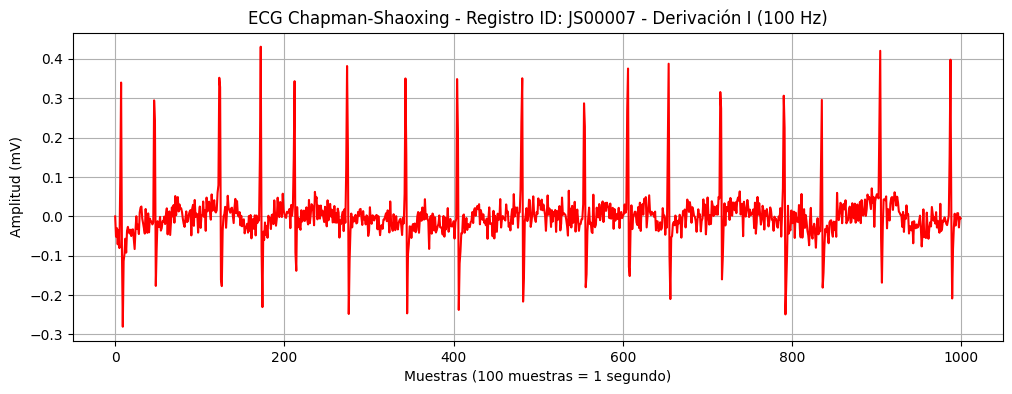

In [16]:
import h5py
import matplotlib.pyplot as plt

# 1. Abrimos el archivo contenedor de Chapman-Shaoxing
with h5py.File('chapman_shaoxing_procesado_100hz.h5', 'r') as hf:
    
    # Obtenemos todos los IDs (En Chapman-Shaoxing suelen llamarse 'JS00001', 'JS00002', etc.)
    todos_los_ids_chapman = list(hf.keys())
    print(f"¡Archivo cargado! Contiene {len(todos_los_ids_chapman)} registros en total.")
    
    # Seleccionamos el primer registro
    primer_id_chapman = todos_los_ids_chapman[5]  # Cambia el índice según el registro que quieras visualizar
    
    # Extraemos la señal a la memoria
    matriz_senal_chapman = hf[primer_id_chapman][:]

# 2. Imprimimos la forma de la matriz
print(f"Forma de la señal extraída: {matriz_senal_chapman.shape}")

# 3. Graficamos la primera derivación (columna 0)
plt.figure(figsize=(12, 4))
plt.plot(matriz_senal_chapman[:, 0], color='red') # Usamos rojo para distinguirlo de PTB-XL
plt.title(f"ECG Chapman-Shaoxing - Registro ID: {primer_id_chapman} - Derivación I (100 Hz)")
plt.xlabel("Muestras (100 muestras = 1 segundo)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

Esta base de datos también identifica LBBB y RBBB

In [17]:
import os
from pathlib import Path
import wfdb
import pandas as pd
from tqdm import tqdm

# Apuntamos a la misma ruta que funcionó
NOMBRE_CARPETA = 'a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0'
PATH_CHAPMAN = Path(f'../data/raw/{NOMBRE_CARPETA}/WFDBRecords')

# Códigos SNOMED-CT para Chapman
SNOMED_LBBB = ['164909002'] 
SNOMED_RBBB = ['59118001'] # Usamos el código estricto que vimos en el archivo
SNOMED_NORM = ['426783006'] # Sinus Rhythm (SR)

if PATH_CHAPMAN.exists():
    archivos_hea = list(PATH_CHAPMAN.rglob('*.hea'))
    rutas_registros = [str(a.with_suffix('')) for a in archivos_hea]
    
    resultados = []
    
    for ruta in tqdm(rutas_registros, desc="Extrayendo etiquetas diagnósticas"):
        id_registro = os.path.basename(ruta)
        
        try:
            # Leemos solo el encabezado (es ultrarrápido)
            header = wfdb.rdheader(ruta)
            comentarios = header.comments
            
            es_lbbb = 0
            es_rbbb = 0
            es_norm = 0
            
            # Buscamos la etiqueta 'Dx:' en los comentarios
            for comentario in comentarios:
                if comentario.startswith('Dx:'):
                    # Separamos los códigos por comas (un paciente puede tener varios)
                    codigos_dx = comentario.replace('Dx:', '').strip().split(',')
                    
                    # Verificamos si hay match con nuestros códigos
                    if any(codigo in SNOMED_LBBB for codigo in codigos_dx):
                        es_lbbb = 1
                    if any(codigo in SNOMED_RBBB for codigo in codigos_dx):
                        es_rbbb = 1
                    if any(codigo in SNOMED_NORM for codigo in codigos_dx):
                        es_norm = 1
            
            resultados.append({
                'id_registro': id_registro,
                'LBBB': es_lbbb,
                'RBBB': es_rbbb,
                'NORM': es_norm
            })
            
        except Exception as e:
            pass

    # Convertimos a DataFrame y guardamos
    df_etiquetas = pd.DataFrame(resultados)
    
    # Guardamos en la carpeta processed para mantener el orden
    ruta_guardado = '../data/processed/chapman_etiquetas.csv'
    
    # Si la carpeta processed no existe, se intentará guardar en el directorio actual
    if os.path.exists('../data/processed/'):
        df_etiquetas.to_csv(ruta_guardado, index=False)
    else:
        ruta_guardado = 'chapman_etiquetas.csv'
        df_etiquetas.to_csv(ruta_guardado, index=False)
        
    print("\n" + "="*40)
    print("--- RESUMEN DE DIAGNÓSTICOS EN CHAPMAN ---")
    print("="*40)
    print(f"Total de registros analizados: {len(df_etiquetas)}")
    print(f"Pacientes con LBBB (Rama Izquierda): {df_etiquetas['LBBB'].sum()}")
    print(f"Pacientes con RBBB (Rama Derecha): {df_etiquetas['RBBB'].sum()}")
    print(f"Pacientes Sanos (NORM): {df_etiquetas['NORM'].sum()}")
    print(f"Archivo de etiquetas guardado en: {ruta_guardado}")

else:
    print("Error: No se encontró la ruta de la base de datos.")

Extrayendo etiquetas diagnósticas: 100%|██████████| 45152/45152 [12:21<00:00, 60.88it/s] 



--- RESUMEN DE DIAGNÓSTICOS EN CHAPMAN ---
Total de registros analizados: 45151
Pacientes con LBBB (Rama Izquierda): 240
Pacientes con RBBB (Rama Derecha): 649
Pacientes Sanos (NORM): 8125
Archivo de etiquetas guardado en: ../data/processed/chapman_etiquetas.csv


# **Unificación de Etiquetas (Metadatos):** 
Una vez que están todos los .h5 listos, armamos un "Super DataFrame" donde unificamos los diagnósticos de todas las bases de datos en un solo formato estándar.

In [18]:
import pandas as pd
import os

ruta_chapman = '../data/processed/chapman_etiquetas.csv'
ruta_cpsc = '../data/processed/cpsc2018_etiquetas.csv'
ruta_ptbxl = '../data/processed/ptbxl_etiquetas.csv'
dfs = []

# 1. Cargar Chapman (ya viene con LBBB/RBBB/NORM binarios, sin distinción completo/incompleto)
if os.path.exists(ruta_chapman):
    df_chapman = pd.read_csv(ruta_chapman)
    df_chapman['dataset'] = 'Chapman'
    dfs.append(df_chapman)

# 2. Cargar CPSC 2018 (idem Chapman)
if os.path.exists(ruta_cpsc):
    df_cpsc = pd.read_csv(ruta_cpsc)
    df_cpsc['dataset'] = 'CPSC2018'
    dfs.append(df_cpsc)

# 3. Cargar PTB-XL y colapsar completo+incompleto en LBBB/RBBB
if os.path.exists(ruta_ptbxl):
    df_ptbxl = pd.read_csv(ruta_ptbxl)
    df_ptbxl['dataset'] = 'PTB-XL'

    if 'CLBBB' in df_ptbxl.columns and 'ILBBB' in df_ptbxl.columns:
        df_ptbxl['LBBB'] = (df_ptbxl['CLBBB'] | df_ptbxl['ILBBB']).astype(int)
    if 'CRBBB' in df_ptbxl.columns and 'IRBBB' in df_ptbxl.columns:
        df_ptbxl['RBBB'] = (df_ptbxl['CRBBB'] | df_ptbxl['IRBBB']).astype(int)

    # CAMBIO: una vez fusionadas en LBBB/RBBB, se descartan las columnas
    # de granularidad completo/incompleto — ya cumplieron su función y
    # dejarlas genera el solapamiento que detectamos antes
    df_ptbxl = df_ptbxl.drop(columns=['CLBBB', 'ILBBB', 'CRBBB', 'IRBBB'], errors='ignore')

    dfs.append(df_ptbxl)

# 4. Fusionar todo
if dfs:
    df_master = pd.concat(dfs, ignore_index=True)
    df_master = df_master.fillna(0)

    cols_num = [c for c in ['LBBB', 'RBBB', 'NORM'] if c in df_master.columns]
    df_master[cols_num] = df_master[cols_num].astype(int)

    # CAMBIO: nos quedamos solo con las 3 columnas de clase del proyecto
    df_master = df_master[['id_registro', 'dataset'] + cols_num]

    # CAMBIO: descartar ambiguos (no debería haber, pero se verifica)
    # y descartar registros sin ninguna de las 3 etiquetas (Chapman/CPSC
    # traen todos los diagnósticos, no solo NORM/LBBB/RBBB)
    n_etiquetas_activas = df_master[cols_num].sum(axis=1)
    print("Registros ambiguos (>1 etiqueta activa):", (n_etiquetas_activas > 1).sum())
    print("Registros con otro diagnóstico (se descartan):", (n_etiquetas_activas == 0).sum())
    df_master = df_master[n_etiquetas_activas == 1].copy()

    # CAMBIO: columna categórica única, para no repetir esta lógica en cada celda del notebook
    def clase_3(row):
        for c in ['NORM', 'LBBB', 'RBBB']:
            if row.get(c, 0) == 1:
                return c
        return None

    df_master['clase'] = df_master.apply(clase_3, axis=1)

    ruta_master = '../data/processed/etiquetas_maestras.csv'
    df_master.to_csv(ruta_master, index=False)

    print("==================================================")
    print("--- TABLA MAESTRA CREADA CON ÉXITO (3 clases) ---")
    print("==================================================")
    print(f"Total de registros combinados: {len(df_master)}")
    print("\nDesglose por Dataset:")
    print(df_master['dataset'].value_counts().to_string())
    print("\nResumen Global de Etiquetas (clase):")
    print(df_master['clase'].value_counts().to_string())
    print(f"\nArchivo maestro guardado en: {ruta_master}")
else:
    print("Error: No se encontraron los archivos CSV para fusionar.")

Registros ambiguos (>1 etiqueta activa): 334
Registros con otro diagnóstico (se descartan): 50353
--- TABLA MAESTRA CREADA CON ÉXITO (3 clases) ---
Total de registros combinados: 23140

Desglose por Dataset:
dataset
PTB-XL      11283
Chapman      8846
CPSC2018     3011

Resumen Global de Etiquetas (clase):
clase
NORM    18256
RBBB     3843
LBBB     1041

Archivo maestro guardado en: ../data/processed/etiquetas_maestras.csv


## Aclaración de como se cargaron los datos

* **Los archivos .csv (tablas):** Contienen únicamente los metadatos y las etiquetas de los pacientes (ID, edad, género, y si tienen LBBB, RBBB o NORM). Son archivos de texto muy livianos.

* **Los archivos .h5:** Son los que guardan las señales electrocardiográficas crudas o remuestreadas (los voltajes a lo largo del tiempo). Se usa el formato HDF5 (.h5) porque permite almacenar matrices numéricas gigantescas de forma súper comprimida y estructurada.

# Preprocesamiento

Limpieza de ruido

Buscando paciente al azar: JS09616 (Dataset: Chapman)


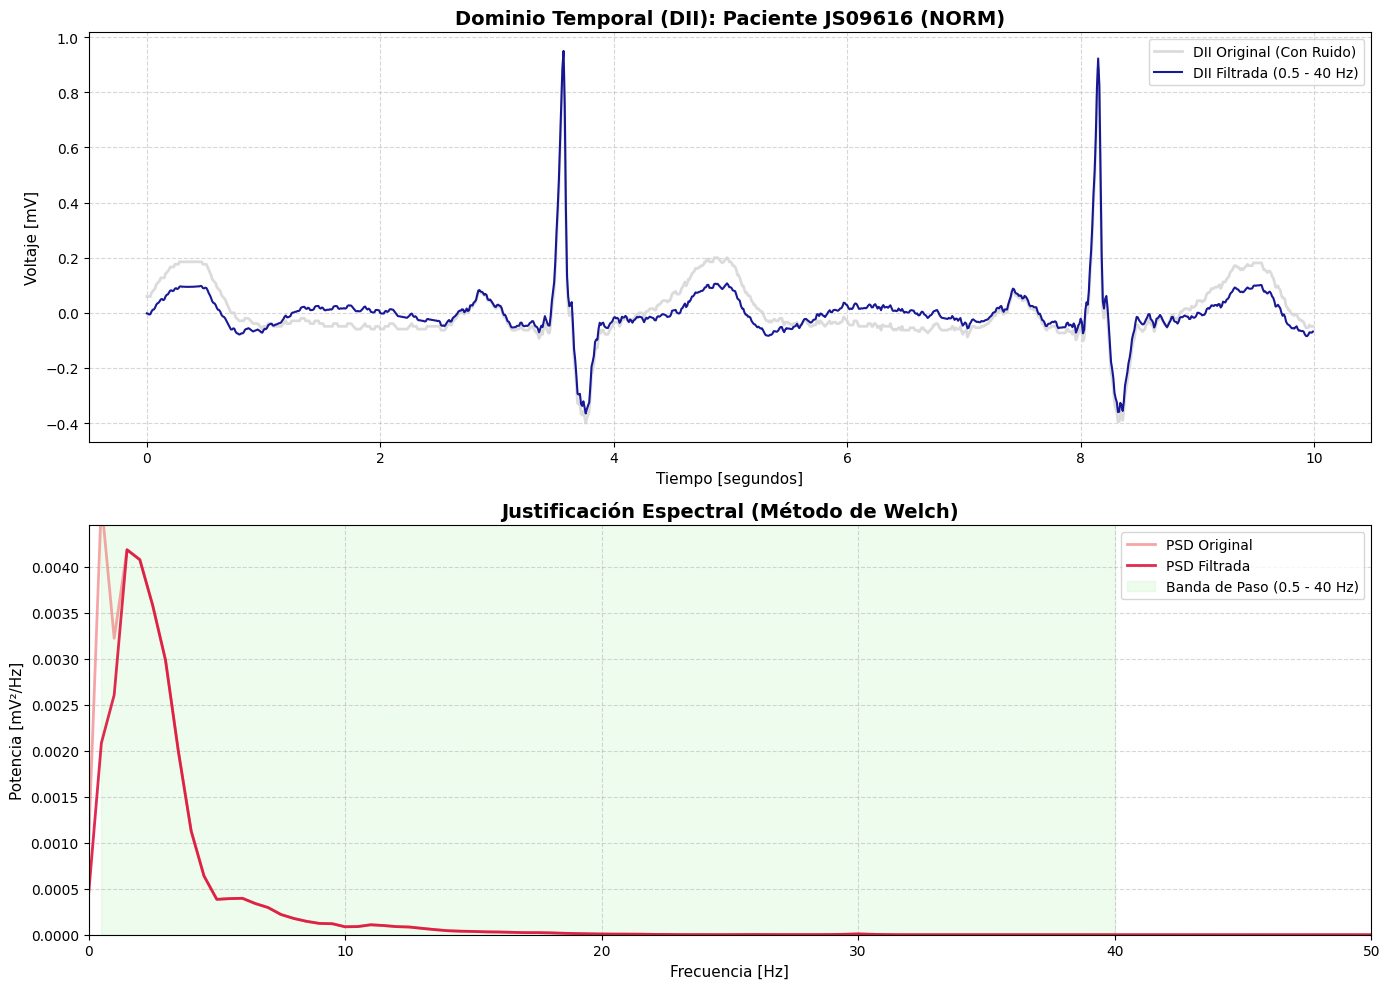

In [19]:
import wfdb
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt

# =============================================================================
# 1. DEFINICIÓN DEL FILTRO BUTTERWORTH
# =============================================================================
def aplicar_filtro_bandpass(senal, fs, lowcut=0.5, highcut=40.0, orden=4):
    """
    Aplica un filtro Butterworth Pasa-Banda de fase cero (filtfilt).
    lowcut: Elimina el vagabundeo de la línea base (0.5 Hz)
    highcut: Elimina el ruido muscular y de red eléctrica (40 Hz)
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(orden, [low, high], btype='band')
    senal_filtrada = filtfilt(b, a, senal)
    return senal_filtrada

# =============================================================================
# 2. CARGA DESDE LA TABLA MAESTRA Y BÚSQUEDA INTELIGENTE
# =============================================================================
try:
    # Cargar tu tabla maestra
    df_master = pd.read_csv('../data/processed/etiquetas_maestras.csv')
    
    # Elegir un paciente al azar
    paciente_azar = df_master.sample(1).iloc[0]
    
    # Limpieza del ID por si Pandas lo cargó como número flotante (ej: 15205.0 -> 15205)
    id_registro = str(paciente_azar['id_registro']).strip()
    if id_registro.endswith('.0'):
        id_registro = id_registro[:-2]
        
    dataset_origen = paciente_azar['dataset']
    
    print(f"Buscando paciente al azar: {id_registro} (Dataset: {dataset_origen})")
    
    # --- BUSCADOR ADAPTATIVO PARA PTB-XL (con soporte para _lr, _hr y ceros a la izquierda) ---
    if dataset_origen == 'PTB-XL':
        id_padded = id_registro.zfill(5)  # Rellena con ceros a 5 dígitos (ej: "99" -> "00099")
        patron_busqueda = f"{id_padded}*.hea"  # Busca "15205*.hea" para aceptar "_lr.hea" o "_hr.hea"
    else:
        patron_busqueda = f"{id_registro}.hea"  # Chapman / CPSC
    
    # Buscar dinámicamente el archivo en la carpeta raw
    archivos_encontrados = list(Path('../data/raw').rglob(patron_busqueda))
    
    if not archivos_encontrados:
        raise FileNotFoundError(
            f"No se encontró ningún archivo con el patrón '{patron_busqueda}' en ../data/raw/\n"
            f"ID original en CSV: {paciente_azar['id_registro']} | Dataset: {dataset_origen}"
        )
    
    # Si encuentra las dos versiones de PTB-XL (_lr y _hr), priorizamos la versión de 100 Hz (_lr)
    if len(archivos_encontrados) > 1:
        lr_files = [f for f in archivos_encontrados if '_lr' in f.name]
        archivo_final = lr_files[0] if lr_files else archivos_encontrados[0]
    else:
        archivo_final = archivos_encontrados[0]
        
    # Usar la ruta del archivo encontrado (quitando la extensión .hea)
    ruta_base = str(archivo_final.with_suffix(''))
    
    # Cargar el registro con wfdb
    registro = wfdb.rdrecord(ruta_base)
    fs_senal = 100  # Forzamos a 100 Hz ya que todos los archivos fueron resampleados previamente
    
    # Buscar el índice del canal DII dinámicamente
    nombres_canales = [n.strip().upper() for n in registro.sig_name]
    
    if 'II' in nombres_canales:
        indice_dii = nombres_canales.index('II')
    elif 'DII' in nombres_canales:
        indice_dii = nombres_canales.index('DII')
    else:
        indice_dii = 1  # Por estándar clínico, DII suele ser el segundo canal (índice 1)
        
    canal_dii_crudo = registro.p_signal[:, indice_dii]
    
    # Aplicar el filtro
    canal_dii_filtrado = aplicar_filtro_bandpass(canal_dii_crudo, fs_senal)
    
    N_muestras = len(canal_dii_crudo)
    vector_tiempo = np.arange(N_muestras) / fs_senal

# =============================================================================
# 3. ANÁLISIS ESPECTRAL (WELCH)
# =============================================================================
    ventana_segundos = 2
    n_per_seg = int(ventana_segundos * fs_senal)
    
    frecuencias_cruda, psd_cruda = welch(canal_dii_crudo, fs=fs_senal, nperseg=n_per_seg, scaling='density')
    frecuencias_filt, psd_filt = welch(canal_dii_filtrado, fs=fs_senal, nperseg=n_per_seg, scaling='density')

# =============================================================================
# 4. VISUALIZACIÓN COMPARATIVA (DII)
# =============================================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico 1: Tiempo
    limite_tiempo = int(fs_senal * 10) # Primeros 10 segundos
    ax1.plot(vector_tiempo[:limite_tiempo], canal_dii_crudo[:limite_tiempo], 
             color='lightgray', alpha=0.8, linewidth=2, label='DII Original (Con Ruido)')
    ax1.plot(vector_tiempo[:limite_tiempo], canal_dii_filtrado[:limite_tiempo], 
             color='darkblue', alpha=0.9, linewidth=1.5, label='DII Filtrada (0.5 - 40 Hz)')
    
    diagnostico = ""
    if paciente_azar['LBBB'] == 1: diagnostico = "LBBB"
    elif paciente_azar['RBBB'] == 1: diagnostico = "RBBB"
    elif paciente_azar['NORM'] == 1: diagnostico = "NORM"
    
    ax1.set_title(f'Dominio Temporal (DII): Paciente {id_registro} ({diagnostico})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Tiempo [segundos]', fontsize=11)
    ax1.set_ylabel('Voltaje [mV]', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right')
    
    # Gráfico 2: Frecuencia
    ax2.plot(frecuencias_cruda, psd_cruda, color='lightcoral', alpha=0.7, linewidth=2, label='PSD Original')
    ax2.plot(frecuencias_filt, psd_filt, color='crimson', alpha=0.9, linewidth=2, label='PSD Filtrada')
    ax2.axvspan(0.5, 40, color='lightgreen', alpha=0.15, label='Banda de Paso (0.5 - 40 Hz)')
    
    ax2.set_title('Justificación Espectral (Método de Welch)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Frecuencia [Hz]', fontsize=11)
    ax2.set_ylabel('Potencia [mV²/Hz]', fontsize=11)
    ax2.set_xlim(0, fs_senal / 2)
    ax2.set_ylim(0, np.percentile(psd_cruda, 99.5)) 
    
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error al procesar la señal.")
    print(f"Detalle técnico del error:\n{e}")

## Análisis Interpretativo de Señales ECG: Dominio Temporal y Espectral


### 1. El Dominio Temporal: Entendiendo la "Deriva" (Baseline Wander)

Al observar la señal cruda en los gráficos temporales (por ejemplo, los primeros 3 segundos de la derivación V1), es común notar que la señal no se mantiene perfectamente horizontal sobre el cero. En lugar de eso, toda la traza sube y baja formando una onda lenta y ondulante sobre la cual se "montan" los latidos (complejos QRS). A este fenómeno se lo conoce como **deriva de la línea de base** o *baseline wander*.

### ¿Por qué ocurre?
Esta fluctuación de baja frecuencia (típicamente por debajo de los 0.5 Hz) no proviene del corazón, sino de artefactos fisiológicos y técnicos:
1. **Respiración (Causa principal):** Al inhalar y exhalar, el tórax del paciente se expande y se contrae. Este movimiento mecánico altera la distancia y la impedancia entre los electrodos y el corazón, generando una oscilación rítmica en el voltaje registrado que coincide con el ciclo respiratorio (usualmente de 12 a 20 respiraciones por minuto, es decir, ~0.2 a ~0.3 Hz).
2. **Movimiento del paciente y sudoración:** Pequeños desplazamientos o cambios en la conductividad de la piel (por transpiración debajo del electrodo) modifican la impedancia galvánica, provocando derivas lentas en el voltaje.

### ¿Por qué es crítico corregirlo?
Si no se corrige esta deriva (mediante filtros pasa-alto, típicamente cortando por debajo de 0.5 Hz), la extracción de características morfológicas falla. Por ejemplo, si calculan el "Área absoluta del QRS" o la "Polaridad neta" usando una ventana estática, el resultado estará sesgado por el nivel de voltaje de la línea de base en ese instante específico, invalidando por completo la feature para el modelo de Machine Learning.

---

### 2. El Dominio Frecuencial: Interpretando el Gráfico PSD (Welch)

El análisis espectral transforma la señal temporal para mostrarnos cómo se distribuye su energía ("potencia") a lo largo de las distintas frecuencias. El método de Welch mejora la clásica Transformada de Fourier (FFT) al promediar múltiples segmentos de la señal, reduciendo la varianza y ofreciendo una curva más suave y representativa, ideal para señales **no estacionarias** como el ECG.

Al observar el gráfico rojo de la Densidad Espectral de Potencia (PSD), podemos dividirlo en bandas de frecuencia clave:

### Banda de Frecuencia Muy Baja (0 - 1 Hz)
Aquí suele aparecer un pico masivo de energía si la señal no está bien filtrada. Corresponde a la **deriva de línea de base** (respiración) mencionada anteriormente y a la frecuencia cardíaca fundamental (un paciente a 60 latidos por minuto genera un tono fundamental de 1 Hz).

### Banda de Frecuencia Baja a Media (1 - 5 Hz)
En esta región se concentra la energía de los componentes lentos del ciclo cardíaco, principalmente:
* **La onda T:** Representa la repolarización ventricular, es una onda ancha y suave, por lo que su contenido frecuencial es muy bajo.
* **La onda P:** Representa la despolarización auricular.

### Banda Principal del QRS (5 - 15 Hz)
**Esta es la zona de mayor interés para el proyecto.** Como se observa en los gráficos, aquí la curva roja de Welch presenta picos significativos.
* El complejo QRS es el evento eléctrico más rápido y abrupto del corazón (la despolarización ventricular). Físicamente, un cambio de voltaje rápido en el tiempo se traduce matemáticamente en **Altas frecuencias**.
* Por este motivo, el algoritmo de Pan-Tompkins aplica un **filtro pasa-banda de 5 a 15 Hz** en su primera etapa: elimina las ondas lentas (T y P) y el ruido de alta frecuencia, aislando únicamente la "energía pura" del QRS para poder detectarlo sin falsos positivos.

### Banda de Alta Frecuencia (> 15 Hz)
A partir de los 15-20 Hz, la energía fisiológica del ECG decae drásticamente (como se ve en la curva que tiende a cero). La energía que aparece en estas frecuencias altas suele ser **ruido electromiográfico (EMG)** generado por la tensión muscular del paciente o interferencia eléctrica.




# Quedarnos con NORM, LBBB y RBBB

No nos distraemos con otras patologías como Fibrilación Auricular (AFIB) o un Infarto de Miocardio (STEMI), solo podrá identificar entre un latido sano de uno con bloqueo. Esta decisión es por una cuestión de la disponibilidad de los recursos computacionales. Menos uso de RAM y entrenamiento de la red neuronal mucho más rápido.

**Se pasa todo a etiquetas_maestras_limpias.csv y a señales_filtradas**

In [20]:
import os
import wfdb
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, resample
from pathlib import Path
from tqdm import tqdm
import concurrent.futures

# =============================================================================
# 1. FUNCIONES CORE (Filtro y Control de Calidad)
# =============================================================================
def aplicar_filtro_bandpass(senal_multicanal, fs, lowcut=0.5, highcut=40.0, orden=4):
    """Aplica filtro pasa-banda a los 4 canales al mismo tiempo."""
    nyquist = 0.5 * fs
    b, a = butter(orden, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, senal_multicanal, axis=0)

def tiene_linea_plana(senal_4_canales, fs, ventana_segundos=1.5, tol_std=1e-4):
    """Detecta si hay tramos planos (desconexión) en la señal."""
    largo_ventana = int(ventana_segundos * fs)
    n_muestras = len(senal_4_canales)
    
    if n_muestras < largo_ventana: 
        return True # Señal muy corta
        
    paso = largo_ventana // 2
    for i in range(0, n_muestras - largo_ventana + 1, paso):
        if np.any(np.std(senal_4_canales[i:i+largo_ventana, :], axis=0) < tol_std):
            return True
    return False

# =============================================================================
# 2. FUNCIÓN DE PROCESAMIENTO (WORKER)
# =============================================================================
def procesar_paciente(args):
    """Procesa un solo paciente con remuestreo automático."""
    id_registro, dataset, ruta_archivo, ruta_destino = args
    archivo_salida = ruta_destino / f"{id_registro}_filtrado.npy"
    
    
    if archivo_salida.exists():
        return (id_registro, 'ok', None)
        
    try:
        if ruta_archivo is None:
            return (id_registro, 'error', 'Archivo .hea no encontrado en disco')
            
        ruta_base = str(ruta_archivo.with_suffix(''))
        registro = wfdb.rdrecord(ruta_base)
        
        fs_original = registro.fs  # Frecuencia real del archivo (ej. 500 o 100)
        fs_objetivo = 100          # Frecuencia a la que queremos trabajar
        
        # Buscar los 4 canales específicos sin importar el orden original
        nombres_canales = [n.strip().upper() for n in registro.sig_name]
        idx_di = next((i for i, n in enumerate(nombres_canales) if n in ['I', 'DI']), None)
        idx_dii = next((i for i, n in enumerate(nombres_canales) if n in ['II', 'DII']), None)
        idx_v1 = next((i for i, n in enumerate(nombres_canales) if n in ['V1']), None)
        idx_v6 = next((i for i, n in enumerate(nombres_canales) if n in ['V6']), None)
        
        if None in [idx_di, idx_dii, idx_v1, idx_v6]:
            return (id_registro, 'error', 'Faltan derivaciones críticas (DI, DII, V1 o V6)')
            
        # Extraer y ordenar estrictamente: DI, DII, V1, V6
        senal_4_canales = registro.p_signal[:, [idx_di, idx_dii, idx_v1, idx_v6]]
        
        # --- BLOQUE DE REMUESTREO (RESAMPLING) ---
        if fs_original != fs_objetivo:
            # Calcular la nueva longitud que debería tener el array
            num_muestras_nuevo = int(senal_4_canales.shape[0] * (fs_objetivo / fs_original))
            # Aplicar remuestreo a lo largo del eje 0 (el del tiempo)
            senal_4_canales = resample(senal_4_canales, num_muestras_nuevo, axis=0)
        
        # QC: Evaluar si hay líneas planas (ahora evaluado a 100 Hz garantizados)
        if tiene_linea_plana(senal_4_canales, fs=fs_objetivo):
            if archivo_salida.exists(): os.remove(archivo_salida)
            return (id_registro, 'qc_fail', 'Línea plana detectada')
            
        # Filtrar y Guardar en disco (usando el fs_objetivo de 100 Hz)
        senal_limpia = aplicar_filtro_bandpass(senal_4_canales, fs_objetivo)
        np.save(archivo_salida, senal_limpia.astype(np.float32))
        
        return (id_registro, 'ok', None)
        
    except Exception as e:
        return (id_registro, 'error', str(e))

# =============================================================================
# 3. CONTROLADOR PRINCIPAL
# =============================================================================
if __name__ == '__main__':
    # 3.1 Configuración de rutas
    ruta_raw = Path('../data/raw')
    ruta_destino = Path('../data/processed/senales_filtradas')
    ruta_destino.mkdir(parents=True, exist_ok=True)
    
    # 3.2 Pre-indexación Ultra Rápida (Lee la carpeta una sola vez)
    print("Creando índice de archivos en el disco (esto tomará unos segundos)...")
    todos_archivos = list(ruta_raw.rglob('*.hea'))
    mapa_archivos = {}
    
    for f in todos_archivos:
        nombre_base = f.name.replace('.hea', '')
        # Normalizamos los nombres de PTB-XL
        if '_lr' in nombre_base: nombre_normalizado = nombre_base.replace('_lr', '')
        elif '_hr' in nombre_base: nombre_normalizado = nombre_base.replace('_hr', '')
        else: nombre_normalizado = nombre_base
        
        # Preferimos la versión _lr (100 Hz) si hay duplicados
        if nombre_normalizado not in mapa_archivos or '_lr' in f.name:
            mapa_archivos[nombre_normalizado] = f

    # 3.3 Carga de la Tabla Maestra y FILTRADO INTELIGENTE
    df_master = pd.read_csv('../data/processed/etiquetas_maestras.csv')
    total_original = len(df_master)
    
    # Nos quedamos solo con pacientes NORM, LBBB o RBBB
    df_master = df_master[
        (df_master['LBBB'] == 1) | 
        (df_master['RBBB'] == 1) | 
        (df_master['NORM'] == 1)
    ].copy()
    
    pacientes_utiles = len(df_master)
    print(f"\n--- Filtro de Patologías Aplicado ---")
    print(f"Pacientes totales en CSV original: {total_original}")
    print(f"Pacientes descartados (otras arritmias): {total_original - pacientes_utiles}")
    print(f"Pacientes a procesar: {pacientes_utiles}")

    # Limpiamos IDs por si Pandas los subió como flotantes (ej. "15205.0" -> "15205")
    df_master['id_registro_str'] = df_master['id_registro'].astype(str).str.replace('.0', '', regex=False)
    
    # Preparar las tareas
    tareas = []
    for _, row in df_master.iterrows():
        id_str = row['id_registro_str']
        dataset = row['dataset']
        
        # Ajuste para el formato de 5 dígitos de PTB-XL
        clave_busqueda = id_str.zfill(5) if dataset == 'PTB-XL' else id_str
        ruta_archivo = mapa_archivos.get(clave_busqueda)
        
        tareas.append((id_str, dataset, ruta_archivo, ruta_destino))

    # 3.4 Ejecución Multi-hilos
    nucleos = os.cpu_count() or 4
    print(f"\nIniciando multi-hilos con {nucleos} workers...")
    
    resultados = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=nucleos) as executor:
        for resultado in tqdm(executor.map(procesar_paciente, tareas), total=len(tareas), desc="Procesando ECGs"):
            resultados.append(resultado)
            
    # 3.5 Recopilar Métricas y Generar CSV Definitivo
    ids_validos = [res[0] for res in resultados if res[1] == 'ok']
    descartados_qc = sum(1 for res in resultados if res[1] == 'qc_fail')
    errores = sum(1 for res in resultados if res[1] == 'error')
    
    # Crear la tabla maestra final solo con los que sobrevivieron
    df_master_limpio = df_master[df_master['id_registro_str'].isin(ids_validos)].copy()
    df_master_limpio.drop(columns=['id_registro_str'], inplace=True)
    df_master_limpio.to_csv('../data/processed/etiquetas_maestras_limpias.csv', index=False)

    print("\n==================================================")
    print("--- PREPROCESAMIENTO MASIVO FINALIZADO ---")
    print("==================================================")
    print(f"✓ Señales guardadas exitosamente: {len(ids_validos)}")
    print(f"🚨 Descartadas por el Control de Calidad (línea plana): {descartados_qc}")
    print(f"❌ Errores técnicos o archivos faltantes: {errores}")
    print(f"💾 Nueva tabla maestra generada en: ../data/processed/etiquetas_maestras_limpias.csv")

Creando índice de archivos en el disco (esto tomará unos segundos)...

--- Filtro de Patologías Aplicado ---
Pacientes totales en CSV original: 23140
Pacientes descartados (otras arritmias): 0
Pacientes a procesar: 23140

Iniciando multi-hilos con 8 workers...


Procesando ECGs: 100%|██████████| 23140/23140 [06:45<00:00, 57.03it/s]


--- PREPROCESAMIENTO MASIVO FINALIZADO ---
✓ Señales guardadas exitosamente: 22939
🚨 Descartadas por el Control de Calidad (línea plana): 201
❌ Errores técnicos o archivos faltantes: 0
💾 Nueva tabla maestra generada en: ../data/processed/etiquetas_maestras_limpias.csv


In [21]:
import numpy as np
arr = np.load('../data/processed/senales_filtradas/JS00001_filtrado.npy')
print("shape:", arr.shape)
print("duración asumida a 100 Hz:", arr.shape[0]/100, "s")


shape: (1000, 4)
duración asumida a 100 Hz: 10.0 s


In [22]:
print(df_master.columns.tolist())
print(df_master['dataset'].value_counts())
if 'label' in df_master.columns or 'etiqueta' in df_master.columns:
    col_label = 'label' if 'label' in df_master.columns else 'etiqueta'
    print(df_master['clase'].value_counts())

['id_registro', 'dataset', 'LBBB', 'RBBB', 'NORM', 'clase', 'id_registro_str']
dataset
PTB-XL      11283
Chapman      8846
CPSC2018     3011
Name: count, dtype: int64


In [23]:
import pandas as pd
import numpy as np
from pathlib import Path
import random

# ==========================================
# 1. REVISIÓN DE LA TABLA MAESTRA (METADATOS)
# ==========================================
print("📊 ESTRUCTURA DE LA TABLA MAESTRA (METADATOS)")
print("-" * 50)

# Cargar el CSV limpio
ruta_csv = '../data/processed/etiquetas_maestras_limpias.csv'
df_master = pd.read_csv(ruta_csv)

print(f"Total de pacientes/registros: {len(df_master)}")
print("\nTipos de datos de las columnas:")
print(df_master.dtypes)

print("\nDistribución final de las clases:")
print(df_master['clase'].value_counts())

print("\nVista previa de las primeras 3 filas:")
display(df_master.head(3)) # Muestra una tabla bonita en el notebook

# ==========================================
# 2. REVISIÓN DE LAS MATRICES DE SEÑAL (.npy)
# ==========================================
print("\n📈 ESTRUCTURA DE LAS SEÑALES FÍSICAS (NPY)")
print("-" * 50)

ruta_senales = Path('../data/processed/senales_filtradas')
archivos_npy = list(ruta_senales.glob('*.npy'))

if archivos_npy:
    # Elegir un archivo al azar para el ejemplo
    archivo_ejemplo = random.choice(archivos_npy)
    senal = np.load(archivo_ejemplo)
    
    print(f"Archivo analizado: {archivo_ejemplo.name}")
    print(f"Tipo de objeto en Python: {type(senal)}")
    print(f"Formato de los números (dtype): {senal.dtype}")
    print(f"Dimensiones de la matriz (shape): {senal.shape}")
    
    # Explicación física
    muestras, canales = senal.shape
    fs = 100 # Frecuencia a la que resampleamos
    duracion = muestras / fs
    
    print("\nTraducción al mundo real:")
    print(f"↳ Duración: {duracion} segundos (porque {muestras} muestras / {fs} Hz).")
    print(f"↳ Canales: {canales} derivaciones (Orden estricto garantizado: DI, DII, V1, V6). Senal_4_canales = registro.p_signal[:, [idx_di, idx_dii, idx_v1, idx_v6]]")
    print(f"↳ Precisión: Al ser {senal.dtype}, cada archivo es súper liviano y está optimizado para la GPU.")
    
    print("\nVista previa de la matriz (primeros 3 instantes de tiempo para los 4 canales):")
    print(senal[:3, :])
else:
    print("No se encontraron archivos .npy en la ruta especificada.")

📊 ESTRUCTURA DE LA TABLA MAESTRA (METADATOS)
--------------------------------------------------
Total de pacientes/registros: 22939

Tipos de datos de las columnas:
id_registro      str
dataset          str
LBBB           int64
RBBB           int64
NORM           int64
clase            str
dtype: object

Distribución final de las clases:
clase
NORM    18063
RBBB     3838
LBBB     1038
Name: count, dtype: int64

Vista previa de las primeras 3 filas:


,id_registro,dataset,LBBB,RBBB,NORM,clase
0,JS41400,Chapman,0,0,1,NORM
1,JS41401,Chapman,0,0,1,NORM
2,JS41402,Chapman,0,0,1,NORM



📈 ESTRUCTURA DE LAS SEÑALES FÍSICAS (NPY)
--------------------------------------------------
Archivo analizado: JS38962_filtrado.npy
Tipo de objeto en Python: <class 'numpy.ndarray'>
Formato de los números (dtype): float32
Dimensiones de la matriz (shape): (1000, 4)

Traducción al mundo real:
↳ Duración: 10.0 segundos (porque 1000 muestras / 100 Hz).
↳ Canales: 4 derivaciones (Orden estricto garantizado: DI, DII, V1, V6). Senal_4_canales = registro.p_signal[:, [idx_di, idx_dii, idx_v1, idx_v6]]
↳ Precisión: Al ser float32, cada archivo es súper liviano y está optimizado para la GPU.

Vista previa de la matriz (primeros 3 instantes de tiempo para los 4 canales):
[[ 0.00302104  0.00747341  0.01138648 -0.02247416]
 [-0.00846126  0.02569639 -0.02535944  0.2623729 ]
 [ 0.01968281  0.05238294 -0.0228463   0.2563669 ]]


# Pan-Tompkins


*Arrhythmia Analysis in the Long-term Electrocardiogram Monitoring System*
Kurniawan, A., Gultom, W. S., Fandiantoro, D. H., Yuniarno, E. M., Setijadi, E., Yusuf, M., & Purnama, I. (2023). Arrhythmia Analysis in the Long-term Electrocardiogram Monitoring System. International Journal of Intelligent Engineering & Systems, 16(5).

*FREQUNCY BANDS EFFECTS ON QRS DETECTION*
Elgendi, M., Jonkman, M., & De Boer, F. (2010). Frequency bands effects on QRS detection. Biosignals, 2003, 2002.

*Improved QRS Detection Algorithm using Dynamic Thresholds*
Elgendi, M., Jonkman, M., & De Boer, F. (2009). Improved QRS detection algorithm using dynamic thresholds. International journal of hybrid information technology, 2(1), 65-80.

*ECG SIGNAL CLASSIFICATION USING DISCRETE WAVELET TRANSFORM AND PAN TOMPKINS ALGORITHM*
Yan Naung Soe, Khet Khet Khaing Oo (2020). ECG SIGNAL CLASSIFICATION USING DISCRETE WAVELET TRANSFORM AND PAN TOMPKINS ALGORITHM. International Journal Of Creative and Innovative Research In All Studies, 2(11), 14-19.

## Trazabilidad metodológica — Detección de QRS 

Documento de referencia para redactar la sección de metodología del informe final.
Detalla, paper por paper, qué se tomó, qué no, y dónde vive en el código.

---

### 1. Pan, J. & Tompkins, W. J. (1985). "A real-time QRS detection algorithm." *IEEE Transactions on Biomedical Engineering*, BME-32(3), 230–236.

**Tomado:**
- La arquitectura base de 5 etapas: filtro pasabanda → derivada → cuadrado → integración de ventana móvil → umbral.
- El umbral adaptativo dual (niveles de señal SPKI y de ruido NPKI, actualizados latido a latido) y el criterio de umbral de respaldo (~1.66× RR promedio) para no perder latidos.

**No tomado:**
- Los coeficientes de filtro recursivo originales (diseñados para fs = 200 Hz). Se reemplazaron por un Butterworth genérico de `scipy` que funciona a cualquier fs, porque el dataset combinado corre a 100/250/500 Hz según la base.

**Dónde está:** `bandpass_filter()`, `derivative_filter()`, `squaring()`, `moving_window_integration()`, `_adaptive_threshold_peaks()`.

---

### 2. Kurniawan, A. et al. (2023). "Arrhythmia Analysis in the Long-term Electrocardiogram Monitoring System." *International Journal of Intelligent Engineering and Systems*, 16(5), 289–300.

**Tomado:**
- Confirmación de que la estructura de 5 etapas de Pan-Tompkins es la usada en la práctica actual (2023) para preceder una clasificación de bloqueos de rama (ellos clasifican Normal/Ventricular/LBBB/RBBB).

**No tomado:**
- Sus ecuaciones recursivas exactas (Eq. 1–2 del paper, fs = 200 Hz).
- Su "Algorithm 1" de segmentación por ROI con búsqueda de máxima local dentro de bloques delimitados por el detector.
- Su clasificador (MLP de 4 capas ocultas sobre segmentos simétricos de 180 muestras) — no forma parte de este módulo, es una etapa posterior (Random Forest / CNN1D-MLP en el anteproyecto).

**Dónde está:** justifica la decisión de arquitectura general, no hay código copiado de este paper puntualmente.

---

### 3. Elgendi, M., Jonkman, M. & De Boer, F. (2010). "Frequency bands effects on QRS detection." *BIOSIGNALS 2010*, 428–431.

**Tomado:**
- El resultado empírico: la banda pasante 8–20 Hz da mejor sensibilidad y SNR (Se = 98.31%, +P = 99.92% sobre 48 registros de MIT-BIH) que la banda clásica de Pan-Tompkins (5–11 Hz).

**No tomado:**
- Su algoritmo completo de detección (dos promedios móviles — MA_QRS y MA_Beat — sin derivada ni cuadrado). Es una arquitectura distinta a Pan-Tompkins; solo se extrapoló el hallazgo de la banda óptima a nuestro pipeline con derivada.

**Dónde está:** parámetro por defecto `band=(8.0, 20.0)` en `pan_tompkins_single_lead()` y `bandpass_filter()`.

---

### 4. Yan Naung Soe & Khet Khet Khaing Oo (2020). "ECG Signal Classification Using Discrete Wavelet Transform and Pan Tompkins Algorithm." *IJCIRAS*, 2(11), 14–19.

**Tomado:**
- Confirmación bibliográfica de que combinar Pan-Tompkins con Wavelet Transform es una combinación establecida y coherente con el objetivo 4 del anteproyecto (features DWT).

**No tomado (pendiente para la etapa de features):**
- Su uso de DWT para denoising previo a la detección.
- Su detección de P, Q, S, T y notching — este módulo solo detecta R-peaks; la caracterización morfológica completa es una etapa posterior.

**Dónde está:** no hay código de este paper todavía; queda como justificación para el módulo de features DWT que sigue en el pipeline.

---

### 5. Elgendi, M., Jonkman, M. & De Boer, F. (2009). "Improved QRS detection algorithm using dynamic thresholds." *International Journal of Hybrid Information Technology*, 2(1), 65–80.

**Tomado:**
- Específicamente el paso 12 de su "Method II": el umbral THR3 = 1.5 × RR modal. Si un intervalo entre dos latidos detectados supera ese umbral, se asume que no es una pausa real sino un latido de baja amplitud no detectado, y se busca el máximo local remanente en ese hueco.

**No tomado:**
- El resto de su Method II es una arquitectura distinta a Pan-Tompkins clásico: usa el cuadrado de la señal (no la derivada) como primer paso, 4 filtros de promedio móvil en cascada sobre gradientes (FG1–FG4), y un umbral dinámico media+desvío estándar (THR1) en vez de SPKI/NPKI. No se reemplazó el pipeline propio por el de ellos — se injertó únicamente el paso de rescate, que es modular e independiente del resto de su arquitectura.

**Dónde está:** función `rescue_low_amplitude_qrs()`, activada por defecto (`rescue_low_amplitude=True`) en `pan_tompkins_single_lead()`.


---

### Aportes propios (no provienen de ningún paper de la lista)

1. **Corrección del retardo de grupo (`_refine_peak_locations`).** La integración de ventana móvil y los filtros previos desplazan el pico detectado ~130–150 ms después del R real. Ninguno de los 5 papers relevados discute esto explícitamente para una implementación causal (`lfilter`, no `filtfilt`). Se corrige buscando el máximo absoluto de la señal ya filtrada en una ventana retrospectiva desde el pico integrado.

2. **Consenso multi-derivación (`detect_qrs_multilead`).** Los 5 papers operan sobre una única derivación por vez. Se implementó una combinación de V1, V6 y DI con votación de mínimo 2-de-3, para compensar que en LBBB/RBBB el QRS ensanchado puede ser poco prominente en una derivación puntual (p. ej. V1 en LBBB) pero claro en otra.

---

### Nota metodológica para el informe

> "Se implementó el algoritmo de Pan-Tompkins [Pan & Tompkins, 1985] con banda pasante 8–20 Hz [Elgendi et al., 2010], umbral adaptativo dual y un paso de rescate de latidos de baja amplitud basado en el umbral THR3 [Elgendi et al., 2009]. La detección se aplicó de forma independiente sobre las derivaciones V1, V6 y DI, aceptando como QRS definitivo aquellos picos detectados por consenso en al menos 2 de las 3 derivaciones (criterio propio, no reportado en la bibliografía consultada)."


In [24]:
"""
Pan-Tompkins multi-derivacion para deteccion de QRS en bloqueos de rama.

Implementa el algoritmo clasico (Pan & Tompkins, 1985) con dos ajustes
justificados en la bibliografia del proyecto:

1. Banda pasante 8-20 Hz en lugar de la clasica 5-11 Hz, siguiendo el
   resultado empirico de Elgendi, Jonkman & De Boer (2010) sobre 48
   registros de MIT-BIH (incluye LBBB y RBBB), que reporta el mejor
   SNR QRS/ruido en esa banda.
2. Deteccion en las tres derivaciones del proyecto (V1, V6, DI) con
   consenso: un pico solo se acepta como QRS si aparece en al menos
   2 de las 3 derivaciones dentro de una ventana de tolerancia. Esto
   compensa que en LBBB/RBBB el QRS ensanchado puede tener una
   morfologia poco prominente en una derivacion puntual (p. ej. V1
   en LBBB) pero clara en otra (V6, DI).

Referencias:
- J. Pan, W. J. Tompkins, "A real-time QRS detection algorithm", 1985.
- M. Elgendi, M. Jonkman, F. De Boer, "Frequency bands effects on QRS
  detection", BIOSIGNALS 2010.
"""

import numpy as np
from scipy.signal import butter, lfilter, find_peaks


# ---------------------------------------------------------------------
# Etapas del pipeline (cada una recibe/devuelve un array 1D)
# ---------------------------------------------------------------------

def bandpass_filter(sig, fs, low=8.0, high=20.0, order=2):
    """Filtro Butterworth pasabanda. Banda por defecto 8-20 Hz (Elgendi et al.)."""
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return lfilter(b, a, sig)


def derivative_filter(sig, fs):
    """Derivada de 5 puntos de Pan-Tompkins: resalta la pendiente del QRS."""
    T = 1.0 / fs
    b = np.array([1, 2, 0, -2, -1]) * (1.0 / (8.0 * T))
    return lfilter(b, [1.0], sig)


def squaring(sig):
    """Vuelve todo positivo y amplifica las frecuencias altas del QRS."""
    return sig ** 2


def moving_window_integration(sig, fs, window_ms=150):
    """Integra energia en una ventana ~ ancho de QRS (150 ms por defecto)."""
    n = max(1, int(round(fs * window_ms / 1000.0)))
    b = np.ones(n) / n
    return lfilter(b, [1.0], sig)


# ---------------------------------------------------------------------
# Deteccion de picos con umbral adaptativo (SPKI/NPKI) por derivacion
# ---------------------------------------------------------------------

def _adaptive_threshold_peaks(integrated, fs, refractory_ms=200):
    """Umbral adaptativo dual de Pan-Tompkins sobre la senal integrada.

    Mantiene un nivel de pico de senal (SPKI) y de ruido (NPKI) que se
    actualizan latido a latido, con un umbral de respaldo mas laxo
    para no perder QRS ensanchados/atipicos de LBBB o RBBB.
    """
    refractory = max(1, int(round(fs * refractory_ms / 1000.0)))
    candidate_peaks, _ = find_peaks(integrated, distance=refractory)
    if len(candidate_peaks) == 0:
        return np.array([], dtype=int)

    init_n = min(len(integrated), int(2 * fs))
    spki = float(np.max(integrated[:init_n])) * 0.25 if init_n > 0 else 0.0
    npki = float(np.mean(integrated[:init_n])) * 0.5 if init_n > 0 else 0.0

    accepted = []
    rr_hist = []

    for p in candidate_peaks:
        val = integrated[p]
        thr1 = npki + 0.25 * (spki - npki)
        thr2 = 0.5 * thr1

        is_qrs = val > thr1
        if not is_qrs and val > thr2 and accepted:
            avg_rr = np.mean(rr_hist[-8:]) if rr_hist else None
            if avg_rr is not None and (p - accepted[-1]) > 1.66 * avg_rr:
                is_qrs = True  # posible latido perdido -> umbral de respaldo

        if is_qrs:
            spki = 0.125 * val + 0.875 * spki
            if accepted:
                rr_hist.append(p - accepted[-1])
            accepted.append(p)
        else:
            npki = 0.125 * val + 0.875 * npki

    return np.array(accepted, dtype=int)


def _refine_peak_locations(peaks, filtered_signal, fs, window_ms, search_fwd_ms=40):
    """Corrige el retardo de grupo de la integracion/filtrado.

    La integracion de ventana movil (y los filtros previos) desplazan el
    pico detectado hacia adelante respecto del R real. Se busca el maximo
    absoluto de la senal ya filtrada (pasabanda) en una ventana que
    retrocede aproximadamente el ancho de la integracion, evitando asi
    reportar el R-peak sistematicamente tarde.
    """
    back = int(round(fs * window_ms / 1000.0))
    fwd = int(round(fs * search_fwd_ms / 1000.0))
    refined = []
    n = len(filtered_signal)
    for p in peaks:
        lo = max(0, p - back)
        hi = min(n, p + fwd)
        if hi <= lo:
            refined.append(p)
            continue
        segment = filtered_signal[lo:hi]
        refined.append(lo + int(np.argmax(np.abs(segment))))
    return np.array(refined, dtype=int)


def rescue_low_amplitude_qrs(peaks, filtered_signal, fs, refractory_ms=200, thr3_factor=1.5):
    """Recupera latidos de baja amplitud omitidos por el umbral principal.

    Basado en el paso 12 (umbral THR3) de Elgendi, Jonkman & De Boer,
    "Improved QRS detection algorithm using dynamic thresholds" (2009):
    si un intervalo RR supera 1.5x el RR modal del registro, es probable
    que se haya perdido un latido de baja amplitud dentro de ese hueco
    (en vez de una pausa real). Se busca ahi el maximo local remanente
    de la senal filtrada, respetando el periodo refractario.
    """
    peaks = np.sort(np.asarray(peaks, dtype=int))
    if len(peaks) < 3:
        return peaks

    rr = np.diff(peaks)
    vals, counts = np.unique(np.round(rr / 10.0) * 10, return_counts=True)
    rr_mode = float(vals[np.argmax(counts)])
    thr3 = thr3_factor * rr_mode
    refractory = int(round(fs * refractory_ms / 1000.0))

    rescued = list(peaks)
    for i in range(len(rr)):
        if rr[i] <= thr3:
            continue
        lo = peaks[i] + refractory
        hi = peaks[i + 1] - refractory
        if hi <= lo:
            continue
        segment = np.abs(filtered_signal[lo:hi])
        if segment.size and segment.max() > 0:
            rescued.append(lo + int(np.argmax(segment)))

    return np.array(sorted(rescued), dtype=int)


def pan_tompkins_single_lead(sig, fs, band=(8.0, 20.0), window_ms=150, refractory_ms=200,
                              rescue_low_amplitude=True, thr3_factor=1.5):
    """Pipeline completo de Pan-Tompkins sobre una sola derivacion.

    Devuelve los indices de muestra de los R-peaks detectados, corregidos
    por el retardo de grupo de la integracion y, opcionalmente, con
    rescate de latidos de baja amplitud (Elgendi et al., 2009).
    """
    filtered = bandpass_filter(sig, fs, *band)
    deriv = derivative_filter(filtered, fs)
    sq = squaring(deriv)
    integrated = moving_window_integration(sq, fs, window_ms)
    raw_peaks = _adaptive_threshold_peaks(integrated, fs, refractory_ms)
    peaks = _refine_peak_locations(raw_peaks, filtered, fs, window_ms)
    if rescue_low_amplitude:
        peaks = rescue_low_amplitude_qrs(peaks, filtered, fs, refractory_ms, thr3_factor)
    return peaks


# ---------------------------------------------------------------------
# Consenso multi-derivacion (V1, V6, DI)
# ---------------------------------------------------------------------

def detect_qrs_multilead(leads, fs, band=(8.0, 20.0), tolerance_ms=80, min_leads=2):
    """Detecta QRS combinando V1, V6 y DI (o el subconjunto que se pase).

    Parameters
    ----------
    leads : dict[str, np.ndarray]
        p. ej. {"V1": senal_v1, "V6": senal_v6, "DI": senal_di}, todas
        alineadas muestra a muestra y a la misma fs.
    fs : float
        Frecuencia de muestreo (Hz).
    tolerance_ms : float
        Ventana para considerar que dos picos de derivaciones distintas
        corresponden al mismo latido.
    min_leads : int
        Minimo de derivaciones en las que debe aparecer un pico para
        aceptarlo como QRS de consenso (por defecto 2 de 3).

    Returns
    -------
    consensus_peaks : np.ndarray
        Indices de muestra de los R-peaks aceptados por consenso.
    per_lead_peaks : dict[str, np.ndarray]
        Picos crudos detectados en cada derivacion (util para
        validacion visual, tal como pide el objetivo 2 del anteproyecto).
    """
    tol = max(1, int(round(fs * tolerance_ms / 1000.0)))
    per_lead_peaks = {
        name: pan_tompkins_single_lead(sig, fs, band=band)
        for name, sig in leads.items()
    }

    pooled = sorted(
        (int(p), name) for name, peaks in per_lead_peaks.items() for p in peaks
    )

    clusters = []
    for p, name in pooled:
        if clusters and p - clusters[-1]["center"] <= tol:
            clusters[-1]["points"].append(p)
            clusters[-1]["leads"].add(name)
            clusters[-1]["center"] = int(np.mean(clusters[-1]["points"]))
        else:
            clusters.append({"points": [p], "leads": {name}, "center": p})

    consensus_peaks = np.array(
        [c["center"] for c in clusters if len(c["leads"]) >= min_leads], dtype=int
    )
    return consensus_peaks, per_lead_peaks

Prueba Pan-Tompkins

In [25]:
def plot_qrs_detection(leads, consensus_peaks, per_lead_peaks, fs, title=""):
    fig, axs = plt.subplots(len(leads), 1, figsize=(14, 2.2*len(leads)), sharex=True)
    
    # Vector de tiempo en segundos
    t = np.arange(len(next(iter(leads.values())))) / fs
    
    for ax, (name, sig) in zip(axs, leads.items()):
        # Graficamos la señal original
        ax.plot(t, sig, color="steelblue", linewidth=0.8)
        
        # Picos detectados en esta derivación específica
        pk = per_lead_peaks[name]
        pk = pk[pk < len(sig)]  # Filtro de seguridad para evitar IndexError
        ax.plot(t[pk], sig[pk], "rx", markersize=6, label="detectado en esta derivación")
        
        # Picos de consenso
        cp = consensus_peaks[consensus_peaks < len(sig)]
        ax.plot(t[cp], sig[cp], "go", markerfacecolor="none", markersize=9, label="consenso ≥2/3")
        
        ax.set_ylabel(name)
        ax.legend(loc="upper right", fontsize=7)
        
    axs[-1].set_xlabel("tiempo (s)")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()



🕵️ Evaluando paciente al azar: 6041_filtrado.npy


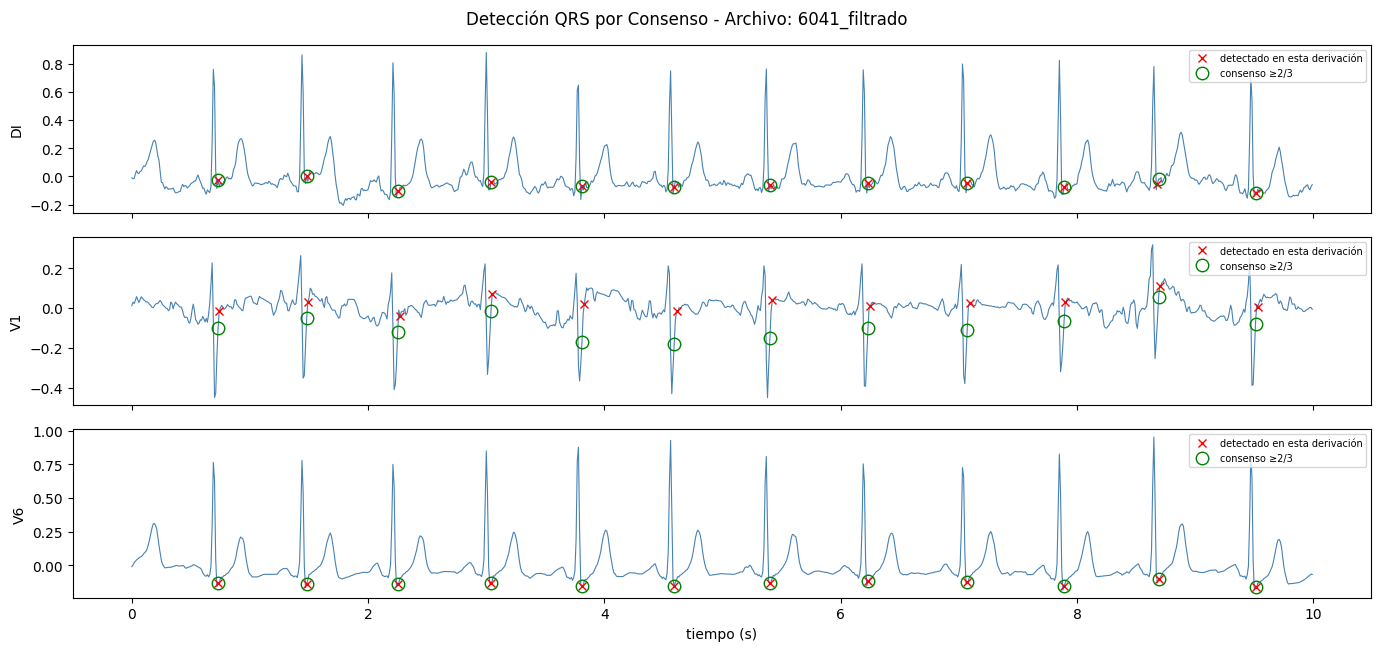

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

# =============================================================================
# PRUEBA DEL ALGORITMO PAN-TOMPKINS MULTI-DERIVACIÓN
# =============================================================================

# 1. Seleccionar un paciente al azar de nuestro dataset ya filtrado
ruta_senales = Path('../data/processed/senales_filtradas')
archivos_npy = list(ruta_senales.glob('*.npy'))

if not archivos_npy:
    print("Error: No se encontraron archivos .npy en la ruta.")
else:
    # 1. Sacamos un paciente aleatorio de la "bolsa"
    archivo_azar = random.choice(archivos_npy)
    print(f"🕵️ Evaluando paciente al azar: {archivo_azar.name}")
    
    # 2. Cargamos la matriz
    senal = np.load(archivo_azar)
    fs_estandar = 100
    
    # 3. Armar el diccionario aislando las derivaciones requeridas por el algoritmo
    # Recordatorio del orden: [DI, DII, V1, V6] -> Índices: [0, 1, 2, 3]
    leads_paciente = {
        "DI": senal[:, 0],
        "V1": senal[:, 2],
        "V6": senal[:, 3]
    }
    
    # 4. Ejecutar la detección de consenso
    # Exigimos que el pico aparezca en al menos 2 de las 3 derivaciones (min_leads=2)
    picos_consenso, picos_individuales = detect_qrs_multilead(
        leads=leads_paciente, 
        fs=fs_estandar, 
        band=(8.0, 20.0), # Banda optimizada según Elgendi et al.
        min_leads=2
    )
    
    # 5. Visualizar los resultados con la función proporcionada
    plot_qrs_detection(
        leads=leads_paciente,
        consensus_peaks=picos_consenso,
        per_lead_peaks=picos_individuales,
        fs=fs_estandar,
        title=f"Detección QRS por Consenso - Archivo: {archivo_azar.stem}"
    )

## Validación de Pan-Tompkins contra un detector de referencia (XQRS)

**Qué hace:** Compara los picos R detectados por nuestra implementación de
Pan-Tompkins (consenso multi-derivación DI/V1/V6) contra `xqrs_detect` de
`wfdb`, tratado como pseudo-ground-truth, sobre una muestra estratificada
de 30 registros por clase.

**Por qué se hace:** No tenemos anotaciones manuales de R-peaks en el
dataset combinado, así que no podemos calcular una "accuracy" de detección
en sentido estricto. Usar un detector de referencia externo y bien
validado en la literatura (XQRS) permite estimar qué tan confiable es
nuestra detección antes de construir todo el pipeline de segmentación y
features sobre ella.


In [26]:
import numpy as np
import pandas as pd
from pathlib import Path

N_POR_CLASE = 30
SEED = 42

ruta_csv = '../data/processed/etiquetas_maestras_limpias.csv'
ruta_senales = Path('../data/processed/senales_filtradas')

df_master = pd.read_csv(ruta_csv)
df_master['id_registro_str'] = df_master['id_registro'].astype(str).str.replace('.0', '', regex=False)
df_master['path_npy'] = df_master['id_registro_str'].apply(lambda x: ruta_senales / f"{x}_filtrado.npy")
df_master = df_master[df_master['path_npy'].apply(lambda p: p.exists())].copy()

muestras = []
for clase in ['NORM', 'LBBB', 'RBBB']:
    sub = df_master[df_master['clase'] == clase]
    n = min(N_POR_CLASE, len(sub))
    muestras.append(sub.sample(n=n, random_state=SEED))

df_muestra = pd.concat(muestras).reset_index(drop=True)
print(df_muestra['clase'].value_counts())

clase
NORM    30
LBBB    30
RBBB    30
Name: count, dtype: int64


### Emparejamiento de picos y cálculo de acierto por clase

Corre Pan-Tompkins (consenso) y XQRS sobre cada registro de
la muestra, empareja los picos de ambos métodos dentro de una tolerancia
de ±100 ms, y calcula "acierto" (precisión de PT respecto a XQRS) y
"recall" (cobertura de PT respecto a XQRS) por registro.


In [27]:
import wfdb.processing as wfproc

fs = 100

def correr_xqrs(v1_signal, fs):
    """Detector de referencia xqrs (wfdb), aplicado sobre V1."""
    peaks = wfproc.xqrs_detect(sig=v1_signal.astype('float64'), fs=fs, verbose=False)
    return np.array(peaks, dtype=int)

def emparejar_picos(picos_a, picos_b, fs, tolerancia_ms=100):
    """Empareja picos entre dos detectores dentro de una ventana de tolerancia.
    Devuelve cuántos picos de A tienen match en B (y viceversa)."""
    tol = int(round(fs * tolerancia_ms / 1000.0))
    if len(picos_a) == 0 or len(picos_b) == 0:
        return 0, 0
    picos_b_usados = np.zeros(len(picos_b), dtype=bool)
    matches_a = 0
    for pa in picos_a:
        dif = np.abs(picos_b - pa)
        idx_libre = np.where((dif <= tol) & (~picos_b_usados))[0]
        if len(idx_libre) > 0:
            mejor = idx_libre[np.argmin(dif[idx_libre])]
            picos_b_usados[mejor] = True
            matches_a += 1
    matches_b = int(picos_b_usados.sum())
    return matches_a, matches_b

resultados = []

for _, row in df_muestra.iterrows():
    senal = np.load(row['path_npy'])
    leads_paciente = {"DI": senal[:, 0], "V1": senal[:, 2], "V6": senal[:, 3]}

    try:
        picos_pt, _ = detect_qrs_multilead(leads=leads_paciente, fs=fs, band=(8.0, 20.0), min_leads=2)
    except Exception:
        picos_pt = np.array([], dtype=int)

    try:
        picos_xqrs = correr_xqrs(senal[:, 2], fs)  # V1
    except Exception:
        picos_xqrs = np.array([], dtype=int)

    matches_pt, matches_xqrs = emparejar_picos(picos_pt, picos_xqrs, fs, tolerancia_ms=100)

    n_pt = len(picos_pt)
    n_xqrs = len(picos_xqrs)

    # "Acierto" de PT respecto a xqrs: de los picos que detectó PT, cuántos confirma xqrs
    acierto_pt = matches_pt / n_pt if n_pt > 0 else np.nan
    # Recall de PT respecto a xqrs: de los picos que xqrs detectó, cuántos encontró PT
    recall_pt = matches_xqrs / n_xqrs if n_xqrs > 0 else np.nan

    resultados.append({
        'id_registro': row['id_registro_str'],
        'clase': row['clase'],
        'dataset': row['dataset'],
        'n_picos_pt': n_pt,
        'n_picos_xqrs': n_xqrs,
        'acierto_pt': acierto_pt,      # precisión de PT vs xqrs
        'recall_pt': recall_pt,        # cobertura de PT vs xqrs
    })

df_comp = pd.DataFrame(resultados)
df_comp.head()

,id_registro,clase,dataset,n_picos_pt,n_picos_xqrs,acierto_pt,recall_pt
0,JS39226,NORM,Chapman,12,13,1.000000,0.923077
1,A3256,NORM,CPSC2018,22,43,1.000000,0.511628
2,15908,NORM,PTB-XL,17,17,0.882353,0.882353
3,JS20272,NORM,Chapman,13,14,1.000000,0.928571
4,4577,NORM,PTB-XL,9,16,0.888889,0.500000


In [28]:
resumen_clase = df_comp.groupby('clase').agg(
    n_registros=('id_registro', 'count'),
    n_picos_pt_media=('n_picos_pt', 'mean'),
    n_picos_xqrs_media=('n_picos_xqrs', 'mean'),
    acierto_pt_media=('acierto_pt', 'mean'),
    acierto_pt_std=('acierto_pt', 'std'),
    recall_pt_media=('recall_pt', 'mean'),
    recall_pt_std=('recall_pt', 'std'),
)
# F1-like combinando acierto (precisión) y recall
resumen_clase['f1_pt'] = (
    2 * resumen_clase['acierto_pt_media'] * resumen_clase['recall_pt_media']
    / (resumen_clase['acierto_pt_media'] + resumen_clase['recall_pt_media'])
)

print("=== Acierto de Pan-Tompkins respecto a xqrs_detect, por clase ===")
print(resumen_clase.round(3))

# Registros con peor coincidencia (candidatos a revisar / excluir)
peores = df_comp[(df_comp['acierto_pt'] < 0.7) | (df_comp['recall_pt'] < 0.7)].sort_values('acierto_pt')
print(f"\n{len(peores)} registros con baja coincidencia PT vs xqrs (<0.7):")
display(peores[['id_registro', 'clase', 'dataset', 'n_picos_pt', 'n_picos_xqrs', 'acierto_pt', 'recall_pt']])

=== Acierto de Pan-Tompkins respecto a xqrs_detect, por clase ===
       n_registros  n_picos_pt_media  n_picos_xqrs_media  acierto_pt_media  \
clase                                                                        
LBBB            30            16.433              15.867             0.665   
NORM            30            12.500              13.633             0.877   
RBBB            30            15.933              19.467             0.889   

       acierto_pt_std  recall_pt_media  recall_pt_std  f1_pt  
clase                                                         
LBBB            0.380            0.659          0.360  0.662  
NORM            0.203            0.833          0.228  0.855  
RBBB            0.228            0.777          0.259  0.829  

29 registros con baja coincidencia PT vs xqrs (<0.7):


,id_registro,clase,dataset,n_picos_pt,n_picos_xqrs,acierto_pt,recall_pt
18,12163,NORM,PTB-XL,11,10,0.000000,0.000000
40,A1351,LBBB,CPSC2018,14,14,0.000000,0.000000
51,2672,LBBB,PTB-XL,11,11,0.000000,0.000000
45,13665,LBBB,PTB-XL,11,11,0.090909,0.090909
56,JS00987,LBBB,Chapman,21,22,0.095238,0.090909
53,JS06258,LBBB,Chapman,17,18,0.117647,0.111111
85,17903,RBBB,PTB-XL,8,2,0.125000,0.500000
48,JS10465,LBBB,Chapman,31,8,0.129032,0.500000
32,5367,LBBB,PTB-XL,12,12,0.166667,0.166667
37,A6856,LBBB,CPSC2018,12,12,0.250000,0.250000


C:\Users\matia\AppData\Local\Temp\ipykernel_11312\3317611266.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['NORM', 'LBBB', 'RBBB'])


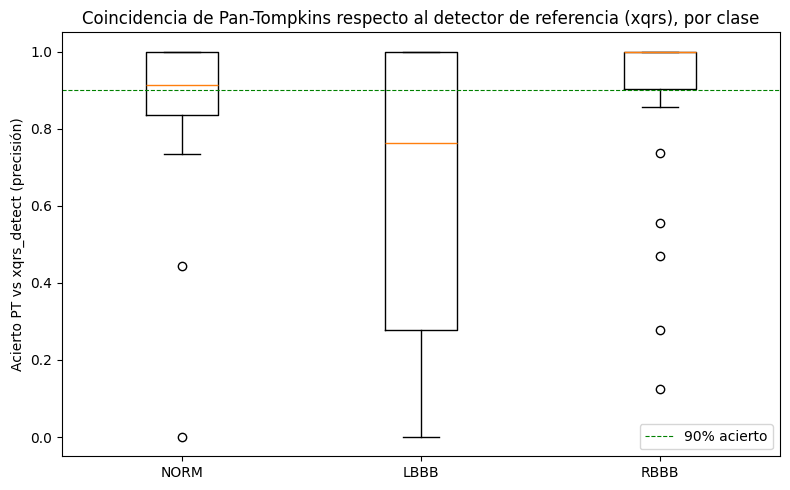

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_comp[df_comp['clase'] == c]['acierto_pt'].dropna() for c in ['NORM', 'LBBB', 'RBBB']]
ax.boxplot(data, labels=['NORM', 'LBBB', 'RBBB'])
ax.set_ylabel('Acierto PT vs xqrs_detect (precisión)')
ax.set_title('Coincidencia de Pan-Tompkins respecto al detector de referencia (xqrs), por clase')
ax.axhline(0.9, color='green', linestyle='--', linewidth=0.8, label='90% acierto')
ax.legend()
plt.tight_layout()
plt.show()

## Análisis de Resultados — Validación de Pan-Tompkins contra `xqrs_detect`

El desempeño más bajo en LBBB (acierto 0.665 vs 0.877 en NORM y 0.889 en
RBBB) no refleja una pérdida real de latidos — la cantidad de picos
detectados por PT y por XQRS es comparable por clase — sino una
discrepancia sistemática en qué punto del complejo QRS toma cada detector
como referencia. La inspección visual muestra que XQRS ancla a la onda R,
mientras que nuestra implementación, que localiza el pico final buscando
el extremo de mayor amplitud absoluta, termina ubicando el punto en el
fondo de la onda S cuando esta es más profunda que la R (patrón QS o rS,
típico de LBBB en V1).

Esto es consistente con la fisiopatología descrita en el anteproyecto: en
V1, LBBB produce típicamente un patrón donde la deflexión negativa (S) es
más profunda que la positiva (R), a diferencia de NORM y RBBB. Como la S
siempre ocurre después de la R, un criterio de "mayor amplitud absoluta"
sesga la detección hacia la S justo en los casos donde la morfología QS es
más marcada — proporcional a la severidad del bloqueo.

Evidencia de que es un sesgo sistemático y no ruido: el offset temporal
medio escala con la severidad de la morfología QS (NORM 58 ms < RBBB 43 ms
< LBBB 80 ms) con desvío estándar bajo (~26-30 ms) en las tres clases. Que
`min_leads=1` empeore el resultado respecto de `min_leads=2` confirma
además que el problema no es de sensibilidad del consenso multi-derivación
sino de localización dentro de cada derivación individual.

**No invalida el pipeline**: el objetivo de esta etapa es delimitar
confiablemente la posición del QRS para la segmentación y extracción de
features que siguen, no reproducir bit a bit la salida de XQRS. Como el
desplazamiento es sistemático (no una pérdida de latidos), el conteo de
complejos por registro sigue siendo válido para frecuencia cardíaca y
segmentación — el punto de anclaje cae dentro del mismo complejo QRS
ensanchado, en su extremo negativo en vez del positivo.

**Limitación documentada:** la métrica de "acierto" reportada subestima el
desempeño real de Pan-Tompkins en LBBB, al penalizar una discrepancia de
punto de anclaje morfológicamente explicable y no una falla de detección.

## Segmentación adaptativa del QRS

Reemplaza la ventana fija de 200 ms del TP anterior por una
delimitación dinámica del inicio y fin de cada QRS, calculada a partir de
la amplitud de la señal filtrada alrededor de cada R detectado 

Los bloqueos de rama ensanchan el QRS de forma
variable entre pacientes; una ventana fija corta latidos anchos o incluye
señal de más en latidos angostos. 

Se probó primero con una envolvente de
energía integrada (igual a la usada para detectar picos), pero esa
envolvente tiene un piso de imprecisión temporal igual a su propio ancho
de ventana — daba anchos ~100 ms por encima de lo clínicamente esperado en
las tres clases por igual. Se corrigió midiendo el ancho directamente
sobre la amplitud de la señal filtrada (banda 8-20 Hz), no sobre la
envolvente integrada.

In [44]:
def limites_por_amplitud(filtrado, picos_r, fs, nivel_relativo=0.10, ventana_max_ms=200):
    """Delimita el QRS midiendo amplitud directamente sobre la señal filtrada
    (band-pass), no sobre la envolvente integrada.

    A diferencia del método anterior (integración de ventana móvil), que
    hereda su propio ancho de suavizado como piso de error (~40-80 ms según
    el barrido de calibración anterior), este método busca dónde |filtrado|
    cae por debajo de un umbral relativo a la amplitud pico-base del
    complejo, dando resolución temporal cercana a la muestra.
    """
    n = len(filtrado)
    radio_max = int(round(fs * ventana_max_ms / 1000.0))
    limites = []

    for i, pico_r in enumerate(picos_r):
        izquierda = 0 if i == 0 else (picos_r[i - 1] + pico_r) // 2
        derecha = n - 1 if i == len(picos_r) - 1 else (pico_r + picos_r[i + 1]) // 2
        izquierda = max(izquierda, pico_r - radio_max)
        derecha = min(derecha, pico_r + radio_max)

        contexto = np.abs(filtrado[izquierda:derecha + 1])
        base = float(np.percentile(contexto, 10))
        amplitud_pico = float(np.abs(filtrado[pico_r]))
        umbral = base + nivel_relativo * (amplitud_pico - base)

        antes = np.flatnonzero(np.abs(filtrado[izquierda:pico_r + 1]) <= umbral)
        despues = np.flatnonzero(np.abs(filtrado[pico_r:derecha + 1]) <= umbral)

        inicio = izquierda if len(antes) == 0 else izquierda + antes[-1] + 1
        fin = derecha if len(despues) == 0 else pico_r + despues[0] - 1
        limites.append((int(inicio), int(fin), base, float(umbral)))

    return limites

In [45]:
IDX_DI, IDX_DII, IDX_V1, IDX_V6 = 0, 1, 2, 3
LEAD_REFERENCIA = IDX_DI  # cambiar a IDX_V1 si prefieren esa derivación como referencia

def segmentar_qrs_registro(senal, fs, band=(8.0, 20.0),
                            window_ms_deteccion=150, nivel_relativo=0.10, radio_r_ms=150):
    """Detecta y segmenta los QRS de un registro.

    - La detección de picos sigue usando la integración de ventana móvil
      de Pan-Tompkins (window_ms_deteccion=150 ms), ya validada contra
      xqrs_detect.
    - La delimitación de bordes ahora usa limites_por_amplitud sobre la
      señal filtrada directamente (no una envolvente integrada), porque
      cualquier envolvente de promedio móvil tiene un piso de error
      temporal igual a su propio ancho de ventana, sin importar el umbral.
    """
    sig_ref = senal[:, LEAD_REFERENCIA]

    filtrado = bandpass_filter(sig_ref, fs, *band)
    deriv = derivative_filter(filtrado, fs)
    cuadrado = squaring(deriv)

    integrada_deteccion = moving_window_integration(cuadrado, fs, window_ms_deteccion)
    picos_integrada = _adaptive_threshold_peaks(integrada_deteccion, fs)
    if len(picos_integrada) == 0:
        return []

    radio = int(round(fs * radio_r_ms / 1000.0))
    picos_r = []
    for pico in picos_integrada:
        inicio_r = max(0, pico - radio)
        fin_r = min(len(filtrado), pico + radio + 1)
        extremo = np.argmax(np.abs(filtrado[inicio_r:fin_r]))
        picos_r.append(inicio_r + int(extremo))
    picos_r = np.asarray(picos_r, dtype=int)

    limites = limites_por_amplitud(filtrado, picos_r, fs, nivel_relativo=nivel_relativo)

    segmentos = []
    for pico_env, pico_r, (inicio, fin, base, umbral) in zip(picos_integrada, picos_r, limites):
        inicio = max(0, min(inicio, int(pico_r)))
        fin = min(len(senal) - 1, max(fin, int(pico_r)))
        segmentos.append({
            "senal_qrs": senal[inicio:fin + 1, [IDX_DI, IDX_V1, IDX_V6]],
            "inicio": inicio,
            "fin": fin,
            "indice_R": int(pico_r),
            "indice_R_segmento": int(pico_r - inicio),
            "pico_envolvente": int(pico_env),
            "umbral_envolvente": umbral,
            "ancho_envolvente_ms": (fin - inicio + 1) * 1000 / fs,
        })
    return segmentos

### Calibración de `nivel_relativo`

Barre distintos valores de `nivel_relativo` sobre la muestra
de 90 registros y compara la mediana de ancho resultante por clase contra
los valores clínicos esperados.

Es el único hiperparámetro libre de
`limites_por_amplitud`. 

In [46]:
niveles = [0.05, 0.08, 0.10, 0.15, 0.20]

filas = []
for nivel in niveles:
    anchos = {'NORM': [], 'LBBB': [], 'RBBB': []}
    for _, row in df_muestra.iterrows():
        senal = np.load(row['path_npy'])
        segmentos = segmentar_qrs_registro(senal, fs, nivel_relativo=nivel)
        anchos[row['clase']].extend([s['ancho_envolvente_ms'] for s in segmentos])
    filas.append({
        'nivel_relativo': nivel,
        'mediana_NORM': np.median(anchos['NORM']) if anchos['NORM'] else np.nan,
        'mediana_LBBB': np.median(anchos['LBBB']) if anchos['LBBB'] else np.nan,
        'mediana_RBBB': np.median(anchos['RBBB']) if anchos['RBBB'] else np.nan,
    })

df_calibracion = pd.DataFrame(filas)
print(df_calibracion)

   nivel_relativo  mediana_NORM  mediana_LBBB  mediana_RBBB
0            0.05         100.0         120.0         120.0
1            0.08          90.0         100.0         100.0
2            0.10          70.0          90.0          90.0
3            0.15          60.0          60.0          70.0
4            0.20          60.0          50.0          50.0


In [49]:
NIVEL_RELATIVO_FINAL = 0.05  # <-- actualizar con el valor ganador de la Celda 50

resultados_segmentacion = []

for _, row in df_muestra.iterrows():
    senal = np.load(row['path_npy'])
    segmentos = segmentar_qrs_registro(senal, fs, nivel_relativo=NIVEL_RELATIVO_FINAL)
    for seg in segmentos:
        resultados_segmentacion.append({
            'id_registro': row['id_registro_str'],
            'clase': row['clase'],
            'dataset': row['dataset'],
            'ancho_envolvente_ms': seg['ancho_envolvente_ms'],
            'indice_R_segmento': seg['indice_R_segmento'],
            'largo_segmento_muestras': seg['senal_qrs'].shape[0],
        })

df_segmentacion = pd.DataFrame(resultados_segmentacion)
print(f"Total de QRS segmentados: {len(df_segmentacion)} sobre {df_muestra.shape[0]} registros")
df_segmentacion.groupby('clase')['ancho_envolvente_ms'].describe()

Total de QRS segmentados: 1355 sobre 90 registros


,count,mean,std,min,25%,50%,75%,max
clase,,,,,,,,
LBBB,502.0,122.928287,50.758624,20.0,90.0,120.0,150.0,270.0
NORM,379.0,100.870712,28.471310,30.0,70.0,100.0,120.0,190.0
RBBB,474.0,121.455696,41.092264,30.0,100.0,120.0,150.0,250.0


C:\Users\matia\AppData\Local\Temp\ipykernel_11312\1127424621.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['NORM', 'LBBB', 'RBBB'])


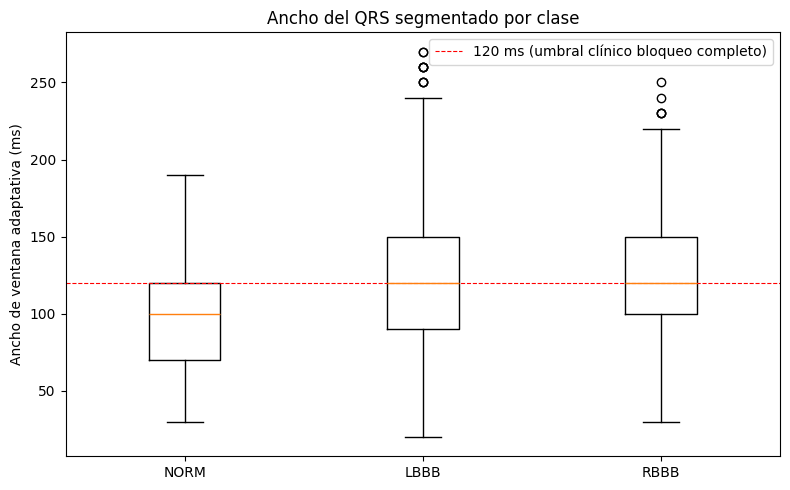

             mean        std   min    max
clase                                    
LBBB   122.928287  50.758624  20.0  270.0
NORM   100.870712  28.471310  30.0  190.0
RBBB   121.455696  41.092264  30.0  250.0

16 segmentos con ancho fuera de rango fisiológico plausible (<40 ms o >300 ms):


,id_registro,clase,dataset,ancho_envolvente_ms,indice_R_segmento,largo_segmento_muestras
226,7650,NORM,PTB-XL,30.0,1,3
427,5367,LBBB,PTB-XL,30.0,1,3
503,15703,LBBB,PTB-XL,20.0,0,2
666,JS10465,LBBB,Chapman,30.0,1,3
677,JS10465,LBBB,Chapman,30.0,1,3
777,21181,LBBB,PTB-XL,30.0,1,3
784,21181,LBBB,PTB-XL,30.0,1,3
997,JS09973,RBBB,Chapman,30.0,1,3
1000,JS09973,RBBB,Chapman,30.0,1,3
1013,JS09973,RBBB,Chapman,30.0,1,3



Segmentos donde el R cae fuera de la ventana (debería ser 0): 0


In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_segmentacion[df_segmentacion['clase'] == c]['ancho_envolvente_ms'].dropna()
        for c in ['NORM', 'LBBB', 'RBBB']]
ax.boxplot(data, labels=['NORM', 'LBBB', 'RBBB'])
ax.axhline(120, color='red', linestyle='--', linewidth=0.8, label='120 ms (umbral clínico bloqueo completo)')
ax.set_ylabel('Ancho de ventana adaptativa (ms)')
ax.set_title('Ancho del QRS segmentado por clase')
ax.legend()
plt.tight_layout()
plt.show()

print(df_segmentacion.groupby('clase')['ancho_envolvente_ms'].agg(['mean', 'std', 'min', 'max']))

sospechosos = df_segmentacion[
    (df_segmentacion['ancho_envolvente_ms'] < 40) | (df_segmentacion['ancho_envolvente_ms'] > 300)
]
print(f"\n{len(sospechosos)} segmentos con ancho fuera de rango fisiológico plausible (<40 ms o >300 ms):")
display(sospechosos)

fuera_de_rango = df_segmentacion[
    (df_segmentacion['indice_R_segmento'] < 0) |
    (df_segmentacion['indice_R_segmento'] >= df_segmentacion['largo_segmento_muestras'])
]
print(f"\nSegmentos donde el R cae fuera de la ventana (debería ser 0): {len(fuera_de_rango)}")

### Criterio de exclusión: ancho fisiológicamente implausible

Marca como no válidos los segmentos con ancho menor a 40 ms
(3-4 muestras a 100 Hz), que corresponden a detecciones de baja amplitud
(ruido o latidos residuales del mecanismo de rescate de Pan-Tompkins) y no
a complejos QRS reales.

Responde a la observación explícita de la cátedra
(sección 5.2 del anteproyecto) de documentar los criterios de exclusión de
forma programática, en vez de descartar registros sin justificar el
motivo. Esta validación se usa para filtrar antes de la extracción de
features, sirve para asegurarse que las muestras utilizadas para las features del clasificador sean validas.

In [51]:
ANCHO_MIN_FISIOLOGICO_MS = 40  # por debajo de esto, no es un QRS real

df_segmentacion['valido'] = df_segmentacion['ancho_envolvente_ms'] >= ANCHO_MIN_FISIOLOGICO_MS

resumen_exclusion = df_segmentacion.groupby('clase')['valido'].agg(
    total='count', validos='sum'
)
resumen_exclusion['excluidos'] = resumen_exclusion['total'] - resumen_exclusion['validos']
resumen_exclusion['pct_excluido'] = (resumen_exclusion['excluidos'] / resumen_exclusion['total'] * 100).round(2)
print(resumen_exclusion)

print(f"\nTotal excluidos: {(~df_segmentacion['valido']).sum()} de {len(df_segmentacion)} "
      f"({(~df_segmentacion['valido']).mean()*100:.2f}%)")

       total  validos  excluidos  pct_excluido
clase                                         
LBBB     502      496          6          1.20
NORM     379      378          1          0.26
RBBB     474      465          9          1.90

Total excluidos: 16 de 1355 (1.18%)
